# Entity Resolution and Golden Record Laboratory

## Notebook 01: Data Acquisition and Initial Audit

**Author:** Kazeem Wale Balogun  
**Project:** Building a Trusted Customer View  
**Purpose:** Load the FEBRL dataset, inspect its structure and conduct an initial data-quality assessment.


In [5]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)


Python executable:
c:\Users\DELL\venvs\entity-resolution-golden-record-lab\Scripts\python.exe

Python version:
3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


In [6]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import recordlinkage
import ipykernel

print("All project libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Recordlinkage version: {recordlinkage.__version__}")
print(f"IPykernel version: {ipykernel.__version__}")

All project libraries imported successfully.
Pandas version: 2.3.3
NumPy version: 2.5.1
Scikit-learn version: 1.9.0
Recordlinkage version: 0.16
IPykernel version: 7.3.0


## 1. Data Acquisition

This project begins with FEBRL Dataset 1, a fictitious person-record dataset designed for testing record-linkage and duplicate-detection methods.

The dataset contains original records and deliberately corrupted duplicate records. The known matching pairs will be retained as the ground truth for evaluating the performance of rule-based and machine-learning approaches.

In [7]:
from recordlinkage.datasets import load_febrl1

print("FEBRL dataset loader imported successfully.")

FEBRL dataset loader imported successfully.


In [8]:
# Load FEBRL Dataset 1 and its known duplicate relationships
febrl_records, true_links = load_febrl1(return_links=True)

print("FEBRL Dataset 1 loaded successfully.")

FEBRL Dataset 1 loaded successfully.


In [9]:
print("Records object type:")
print(type(febrl_records))

print("\nTrue-links object type:")
print(type(true_links))

Records object type:
<class 'pandas.core.frame.DataFrame'>

True-links object type:
<class 'pandas.core.indexes.multi.MultiIndex'>


### 1.1 Dataset Dimensions

In [10]:
number_of_records, number_of_columns = febrl_records.shape
number_of_true_matches = len(true_links)

print(f"Number of records: {number_of_records:,}")
print(f"Number of columns: {number_of_columns}")
print(f"Number of known duplicate pairs: {number_of_true_matches:,}")

Number of records: 1,000
Number of columns: 10
Number of known duplicate pairs: 500


In [11]:
print("Dataset columns:")

for column_number, column_name in enumerate(
    febrl_records.columns,
    start=1
):
    print(f"{column_number}. {column_name}")

Dataset columns:
1. given_name
2. surname
3. street_number
4. address_1
5. address_2
6. suburb
7. postcode
8. state
9. date_of_birth
10. soc_sec_id


### 1.2 Initial Record Inspection

In [12]:
febrl_records.head()

,given_name,surname,street_number,address_1,address_2,suburb,postcode,state,date_of_birth,soc_sec_id
rec_id,,,,,,,,,,
rec-223-org,NaN,waller,6,tullaroop street,willaroo,st james,4011,wa,19081209,6988048
rec-122-org,lachlan,berry,69,giblin street,killarney,bittern,4814,qld,19990219,7364009
rec-373-org,deakin,sondergeld,48,goldfinch circuit,kooltuo,canterbury,2776,vic,19600210,2635962
rec-10-dup-0,kayla,harrington,NaN,maltby circuit,coaling,coolaroo,3465,nsw,19150612,9004242
rec-227-org,luke,purdon,23,ramsay place,mirani,garbutt,2260,vic,19831024,8099933


In [13]:
print("Index name:")
print(febrl_records.index.name)

print("\nFirst ten record identifiers:")
print(febrl_records.index[:10].tolist())

Index name:
rec_id

First ten record identifiers:
['rec-223-org', 'rec-122-org', 'rec-373-org', 'rec-10-dup-0', 'rec-227-org', 'rec-6-dup-0', 'rec-190-dup-0', 'rec-294-org', 'rec-206-dup-0', 'rec-344-org']


### 1.3 Known Duplicate Relationships

In [14]:
print("First ten known duplicate pairs:")

for record_id_1, record_id_2 in list(true_links[:10]):
    print(f"{record_id_1}  <->  {record_id_2}")

First ten known duplicate pairs:
rec-344-dup-0  <->  rec-344-org
rec-251-org  <->  rec-251-dup-0
rec-335-dup-0  <->  rec-335-org
rec-23-dup-0  <->  rec-23-org
rec-382-org  <->  rec-382-dup-0
rec-70-dup-0  <->  rec-70-org
rec-291-org  <->  rec-291-dup-0
rec-179-org  <->  rec-179-dup-0
rec-452-dup-0  <->  rec-452-org
rec-383-org  <->  rec-383-dup-0


In [15]:
# Select the first known duplicate pair
first_match_id, second_match_id = true_links[0]

print("First known duplicate pair:")
print(first_match_id, "<->", second_match_id)

febrl_records.loc[[first_match_id, second_match_id]]

First known duplicate pair:
rec-344-dup-0 <-> rec-344-org


,given_name,surname,street_number,address_1,address_2,suburb,postcode,state,date_of_birth,soc_sec_id
rec_id,,,,,,,,,,
rec-344-dup-0,NaN,stephenson,52,NaN,north stirilng downs,coolaroo,2259,qld,19630521,1797144
rec-344-org,NaN,julius,52,florey drive,north stirling downs,coolaroo,2259,qld,19630521,1797144


### Initial Observation

The selected record pair represents the same underlying person but contains differences across one or more identifying attributes. These variations illustrate why exact matching alone may fail to identify duplicate customer records.

Further analysis will determine which fields are complete, which types of variations occur most frequently and which attributes provide the strongest evidence for entity resolution.

## 2. Initial Data Quality Audit

The initial audit evaluates the structure, completeness, uniqueness and consistency of the FEBRL customer records before duplicate-detection rules or machine-learning models are developed.

Understanding the condition of the source data is essential because entity-resolution performance depends on the availability and reliability of the attributes used to compare records.

In [16]:
from pathlib import Path

current_working_directory = Path.cwd()

print("Current notebook working directory:")
print(current_working_directory)

Current notebook working directory:
c:\Users\DELL\OneDrive\Documents\GitHub\entity-resolution-golden-record-lab\notebooks


### 2.1 Dataset Structure

In [17]:
row_count, column_count = febrl_records.shape

print("FEBRL Dataset 1 structural overview")
print("-----------------------------------")
print(f"Number of records: {row_count:,}")
print(f"Number of columns: {column_count}")
print(f"Number of known duplicate pairs: {len(true_links):,}")
print(f"Index name: {febrl_records.index.name}")
print(f"Are record identifiers unique? {febrl_records.index.is_unique}")

FEBRL Dataset 1 structural overview
-----------------------------------
Number of records: 1,000
Number of columns: 10
Number of known duplicate pairs: 500
Index name: rec_id
Are record identifiers unique? True


### 2.2 Field Completeness and Uniqueness

In [18]:
data_quality_summary = pd.DataFrame({
    "data_type": febrl_records.dtypes.astype(str),
    "non_null_count": febrl_records.notna().sum(),
    "missing_count": febrl_records.isna().sum(),
    "missing_percentage": (
        febrl_records.isna().mean() * 100
    ).round(2),
    "unique_value_count": febrl_records.nunique(dropna=True),
    "unique_percentage": (
        febrl_records.nunique(dropna=True)
        .div(len(febrl_records))
        .mul(100)
    ).round(2)
})

data_quality_summary = data_quality_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

data_quality_summary

,data_type,non_null_count,missing_count,missing_percentage,unique_value_count,unique_percentage
address_2,object,885,115,11.5,585,58.5
street_number,object,955,45,4.5,154,15.4
given_name,object,956,44,4.4,378,37.8
date_of_birth,object,959,41,4.1,513,51.3
address_1,object,975,25,2.5,618,61.8
surname,object,982,18,1.8,494,49.4
suburb,object,982,18,1.8,520,52.0
state,object,985,15,1.5,17,1.7
postcode,object,1000,0,0.0,451,45.1
soc_sec_id,object,1000,0,0.0,550,55.0


### 2.3 Blank Strings and Whitespace

In [19]:
text_columns = febrl_records.select_dtypes(
    include=["object", "string"]
).columns.tolist()

blank_string_counts = {}
whitespace_issue_counts = {}

for column in text_columns:
    values = febrl_records[column].astype("string")

    blank_string_counts[column] = (
        values.str.strip()
        .eq("")
        .fillna(False)
        .sum()
    )

    whitespace_issue_counts[column] = (
        values.notna()
        & values.ne(values.str.strip())
    ).sum()

text_quality_summary = pd.DataFrame({
    "blank_string_count": pd.Series(blank_string_counts),
    "leading_or_trailing_space_count": pd.Series(
        whitespace_issue_counts
    )
})

text_quality_summary = text_quality_summary.sort_values(
    by=[
        "blank_string_count",
        "leading_or_trailing_space_count"
    ],
    ascending=False
)

text_quality_summary

,blank_string_count,leading_or_trailing_space_count
given_name,0,0
surname,0,0
street_number,0,0
address_1,0,0
address_2,0,0
suburb,0,0
postcode,0,0
state,0,0
date_of_birth,0,0
soc_sec_id,0,0


### 2.4 Exact Duplicate Records

In [20]:
exact_duplicate_records = febrl_records.duplicated().sum()

records_in_exact_duplicate_groups = (
    febrl_records.duplicated(keep=False).sum()
)

print(f"Exact duplicate records: {exact_duplicate_records:,}")
print(
    "Records belonging to exact duplicate groups: "
    f"{records_in_exact_duplicate_groups:,}"
)

Exact duplicate records: 0
Records belonging to exact duplicate groups: 0


**Interpretation:** Exact-row duplication does not capture the full entity-resolution problem. Records may refer to the same underlying person while containing spelling errors, missing attributes, transpositions or formatting differences. Approximate comparison methods are therefore required.

### 2.5 Field Completeness Visualisation

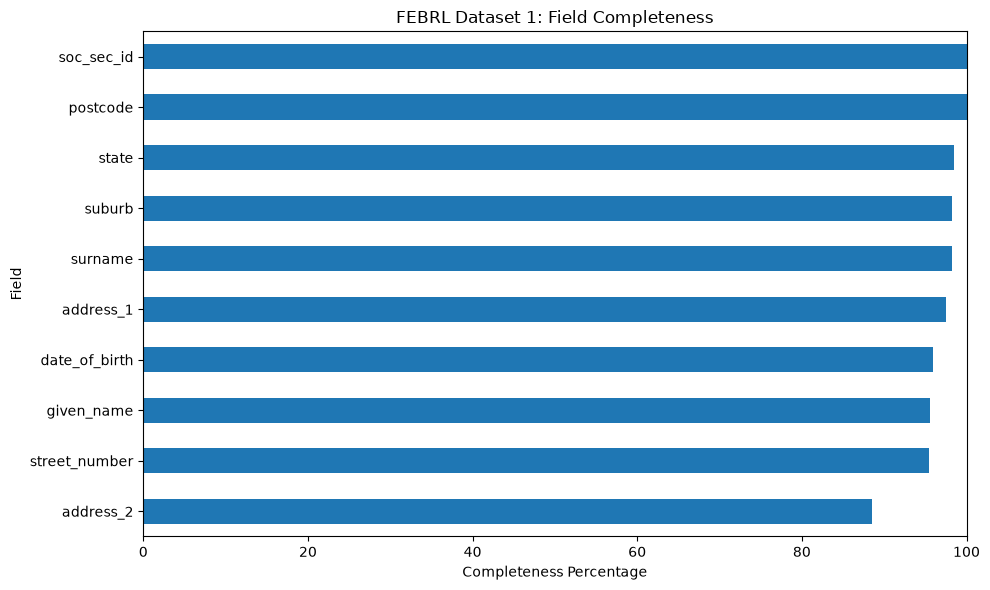

In [21]:
import matplotlib.pyplot as plt

field_completeness = (
    febrl_records.notna().mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(10, 6))
field_completeness.plot(kind="barh")

plt.title("FEBRL Dataset 1: Field Completeness")
plt.xlabel("Completeness Percentage")
plt.ylabel("Field")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### 2.6 Initial Audit Observations

The structural and completeness audit produced the following preliminary observations:

1. **Dataset size:** The dataset contains 1,000 records and 500 known duplicate relationships.

2. **Record identifiers:** The source record identifiers are unique and can therefore be used to track individual records and matching pairs.

3. **Most complete fields:** `soc_sec_id` and `postcode` are fully populated, with no missing values. `state`, `suburb`, and `surname` are also highly complete, with missingness of 1.8% or less.

4. **Least complete fields:** `address_2` has the highest level of missingness at 11.5%, followed by `street_number` at 4.5%, `given_name` at 4.4%, `date_of_birth` at 4.1%, and `address_1` at 2.5%.

5. **Exact duplicates:** No exact duplicate rows were identified. This confirms that the 500 known duplicate relationships contain variations or errors that prevent them from being detected through exact-row comparison.

6. **Formatting issues:** No blank strings or leading or trailing whitespace were detected. Missing values appear to be stored consistently as null values rather than as empty or space-filled strings.

7. **Uniqueness and matching value:** Completeness and uniqueness vary considerably across fields. Although `soc_sec_id` and `postcode` are complete, they contain 550 and 451 unique values respectively across 1,000 records. This indicates that no single field should automatically be treated as sufficient matching evidence.

8. **Entity-resolution implication:** The absence of exact duplicates, combined with missing and inconsistent identifying attributes, demonstrates the need to combine evidence across multiple fields. Approximate matching and carefully selected similarity measures will be required to identify records that refer to the same underlying person.

In [22]:
# Summarise the main findings from the initial data-quality audit

most_complete_fields = (
    data_quality_summary
    .sort_values(
        by=["missing_percentage", "unique_percentage"],
        ascending=[True, False]
    )
    .head(5)
)

least_complete_fields = (
    data_quality_summary
    .sort_values(
        by="missing_percentage",
        ascending=False
    )
    .head(5)
)

formatting_issues = text_quality_summary[
    (text_quality_summary["blank_string_count"] > 0)
    | (
        text_quality_summary[
            "leading_or_trailing_space_count"
        ] > 0
    )
]

exact_duplicate_records = febrl_records.duplicated().sum()

records_in_exact_duplicate_groups = (
    febrl_records.duplicated(keep=False).sum()
)

print("MOST COMPLETE FIELDS")
display(
    most_complete_fields[
        [
            "missing_count",
            "missing_percentage",
            "unique_value_count"
        ]
    ]
)

print("\nLEAST COMPLETE FIELDS")
display(
    least_complete_fields[
        [
            "missing_count",
            "missing_percentage",
            "unique_value_count"
        ]
    ]
)

print("\nFORMATTING ISSUES")
if formatting_issues.empty:
    print("No blank strings or surrounding whitespace detected.")
else:
    display(formatting_issues)

print("\nEXACT DUPLICATE RESULTS")
print(f"Exact duplicate records: {exact_duplicate_records:,}")
print(
    "Records belonging to exact duplicate groups: "
    f"{records_in_exact_duplicate_groups:,}"
)

MOST COMPLETE FIELDS


,missing_count,missing_percentage,unique_value_count
soc_sec_id,0,0.0,550
postcode,0,0.0,451
state,15,1.5,17
suburb,18,1.8,520
surname,18,1.8,494



LEAST COMPLETE FIELDS


,missing_count,missing_percentage,unique_value_count
address_2,115,11.5,585
street_number,45,4.5,154
given_name,44,4.4,378
date_of_birth,41,4.1,513
address_1,25,2.5,618



FORMATTING ISSUES
No blank strings or surrounding whitespace detected.

EXACT DUPLICATE RESULTS
Exact duplicate records: 0
Records belonging to exact duplicate groups: 0


## 3. Field-Level Validity and Standardisation Audit

This section examines whether individual fields follow consistent formats and plausible value patterns. The objective is to identify issues that may affect comparison, standardisation, feature engineering and duplicate-detection performance.

Validation rules will be developed only after the existing value patterns have been examined.

### 3.1 Value Patterns and Field Lengths

In [23]:
fields_for_pattern_review = [
    "given_name",
    "surname",
    "street_number",
    "address_1",
    "address_2",
    "suburb",
    "postcode",
    "state",
    "date_of_birth",
    "soc_sec_id"
]

field_pattern_summary = []

for column in fields_for_pattern_review:
    values = (
        febrl_records[column]
        .astype("string")
        .dropna()
        .str.strip()
    )

    value_lengths = values.str.len()

    field_pattern_summary.append({
        "field": column,
        "non_null_count": len(values),
        "minimum_length": int(value_lengths.min()),
        "median_length": float(value_lengths.median()),
        "maximum_length": int(value_lengths.max()),
        "unique_value_count": values.nunique()
    })

field_pattern_summary = pd.DataFrame(field_pattern_summary)

field_pattern_summary

,field,non_null_count,minimum_length,median_length,maximum_length,unique_value_count
0,given_name,956,3,6.0,15,378
1,surname,982,2,6.0,17,494
2,street_number,955,1,2.0,4,154
3,address_1,975,6,14.0,38,618
4,address_2,885,4,10.0,41,585
5,suburb,982,4,9.0,18,520
6,postcode,1000,4,4.0,4,451
7,state,985,2,3.0,3,17
8,date_of_birth,959,8,8.0,8,513
9,soc_sec_id,1000,7,7.0,7,550


In [24]:
for column in fields_for_pattern_review:
    sample_values = (
        febrl_records[column]
        .dropna()
        .astype("string")
        .drop_duplicates()
        .head(10)
        .tolist()
    )

    print(f"\n{column.upper()}")
    print("-" * len(column))

    for value in sample_values:
        print(value)


GIVEN_NAME
----------
lachlan
deakin
kayla
luke
darcie
william
abbey
isabella
anthony
alia

SURNAME
-------
waller
berry
sondergeld
harrington
purdon
trevorrow
turtur
bishop
lombardi
julius

STREET_NUMBER
-------------
6
69
48
23
16
10
21
36
52
13

ADDRESS_1
---------
tullaroop street
giblin street
goldfinch circuit
maltby circuit
ramsay place
dumas street
blacket street
neworra place
yerralee road
florey drive

ADDRESS_2
---------
willaroo
killarney
kooltuo
coaling
mirani
2/98-latchford barracks
eureka
apmnt 65
leisure living vlge
north stirling downs

SUBURB
------
st james
bittern
canterbury
coolaroo
garbutt
mount immaney
beverly hills
worongary
carlsruhe
yass

POSTCODE
--------
4011
4814
2776
3465
2260
2281
2263
6225
3149
2259

STATE
-----
wa
qld
vic
nsw
act
sa
vix
tas
nrw
nsq

DATE_OF_BIRTH
-------------
19081209
19990219
19600210
19150612
19831024
19530313
19490130
19870919
19630521
19870510

SOC_SEC_ID
----------
6988048
7364009
2635962
9004242
8099933
4811642
2025650
9773843
1

### Field-Pattern Observations

The field-length profile identifies three different structural patterns:

1. `postcode`, `date_of_birth`, and `soc_sec_id` have fixed lengths of 4, 8, and 7 characters respectively. These fields are suitable for pattern and format validation.

2. `state` contains values between two and three characters. This may reflect legitimate Australian state and territory abbreviations rather than a data-quality problem.

3. Names, addresses, and suburbs contain variable-length text values. Their length ranges appear plausible, but further inspection is required to identify punctuation, spelling variation, numeric contamination, and other inconsistencies.

4. `address_1` contains the highest number of distinct values among the reviewed fields, while `street_number` contains relatively few distinct values. Neither field should be used independently to identify a customer.

5. Field length alone cannot establish validity. Representative values and character patterns must be examined before formal validation rules are applied.

### 3.2 Representative Source Values

In [25]:
for column in fields_for_pattern_review:
    sample_values = (
        febrl_records[column]
        .dropna()
        .astype("string")
        .drop_duplicates()
        .head(10)
        .tolist()
    )

    print(f"\n{column.upper()}")
    print("-" * len(column))

    for value in sample_values:
        print(value)


GIVEN_NAME
----------
lachlan
deakin
kayla
luke
darcie
william
abbey
isabella
anthony
alia

SURNAME
-------
waller
berry
sondergeld
harrington
purdon
trevorrow
turtur
bishop
lombardi
julius

STREET_NUMBER
-------------
6
69
48
23
16
10
21
36
52
13

ADDRESS_1
---------
tullaroop street
giblin street
goldfinch circuit
maltby circuit
ramsay place
dumas street
blacket street
neworra place
yerralee road
florey drive

ADDRESS_2
---------
willaroo
killarney
kooltuo
coaling
mirani
2/98-latchford barracks
eureka
apmnt 65
leisure living vlge
north stirling downs

SUBURB
------
st james
bittern
canterbury
coolaroo
garbutt
mount immaney
beverly hills
worongary
carlsruhe
yass

POSTCODE
--------
4011
4814
2776
3465
2260
2281
2263
6225
3149
2259

STATE
-----
wa
qld
vic
nsw
act
sa
vix
tas
nrw
nsq

DATE_OF_BIRTH
-------------
19081209
19990219
19600210
19150612
19831024
19530313
19490130
19870919
19630521
19870510

SOC_SEC_ID
----------
6988048
7364009
2635962
9004242
8099933
4811642
2025650
9773843
1

In [26]:
state_values = sorted(
    febrl_records["state"]
    .dropna()
    .astype("string")
    .unique()
    .tolist()
)

print("Distinct state values:")
for value in state_values:
    print(repr(value))

Distinct state values:
'act'
'as'
'gas'
'msw'
'nrw'
'nsq'
'nsw'
'nt'
'qdl'
'qld'
'sa'
'tas'
'ua'
'vci'
'vic'
'vix'
'wa'


In [27]:
fixed_format_fields = [
    "postcode",
    "date_of_birth",
    "soc_sec_id"
]

for column in fixed_format_fields:
    print(f"\n{column.upper()} SAMPLE VALUES")
    print("-" * 30)

    sample_values = (
        febrl_records[column]
        .dropna()
        .astype("string")
        .drop_duplicates()
        .head(20)
        .tolist()
    )

    for value in sample_values:
        print(repr(value))


POSTCODE SAMPLE VALUES
------------------------------
'4011'
'4814'
'2776'
'3465'
'2260'
'2281'
'2263'
'6225'
'3149'
'2259'
'2594'
'4870'
'2477'
'6152'
'6210'
'2226'
'2794'
'2906'
'2528'
'3029'

DATE_OF_BIRTH SAMPLE VALUES
------------------------------
'19081209'
'19990219'
'19600210'
'19150612'
'19831024'
'19530313'
'19490130'
'19870919'
'19630521'
'19870510'
'19650714'
'19730924'
'19790418'
'19041118'
'19910424'
'19900909'
'19140707'
'19691123'
'19231209'
'19920711'

SOC_SEC_ID SAMPLE VALUES
------------------------------
'6988048'
'7364009'
'2635962'
'9004242'
'8099933'
'4811642'
'2025650'
'9773843'
'1613132'
'1797144'
'7661096'
'2790666'
'6558077'
'1975340'
'7994055'
'6426415'
'3877160'
'2534242'
'2624157'
'5107876'


### 3.3 Fixed-Format Field Validation

The sample values indicate that `postcode` should contain four numeric characters, `date_of_birth` should follow the `YYYYMMDD` format, and `soc_sec_id` should contain seven numeric characters.

The following tests evaluate format consistency across all non-missing values. These checks assess structural validity only. They do not confirm that a postcode is officially allocated or that an identifier represents a real person.

In [28]:
postcode_values = (
    febrl_records["postcode"]
    .astype("string")
    .str.strip()
)

postcode_valid_format = postcode_values.str.fullmatch(
    r"\d{4}",
    na=False
)

postcode_non_null = postcode_values.notna()

print("POSTCODE FORMAT VALIDATION")
print("--------------------------")
print(f"Non-null values: {postcode_non_null.sum():,}")
print(
    "Valid four-digit values: "
    f"{(postcode_valid_format & postcode_non_null).sum():,}"
)
print(
    "Invalid non-null values: "
    f"{(postcode_non_null & ~postcode_valid_format).sum():,}"
)

POSTCODE FORMAT VALIDATION
--------------------------
Non-null values: 1,000
Valid four-digit values: 1,000
Invalid non-null values: 0


In [29]:
date_of_birth_values = (
    febrl_records["date_of_birth"]
    .astype("string")
    .str.strip()
)

date_of_birth_non_null = date_of_birth_values.notna()

parsed_date_of_birth = pd.to_datetime(
    date_of_birth_values,
    format="%Y%m%d",
    errors="coerce"
)

date_of_birth_valid_format = parsed_date_of_birth.notna()

print("DATE OF BIRTH FORMAT VALIDATION")
print("--------------------------------")
print(f"Non-null values: {date_of_birth_non_null.sum():,}")
print(
    "Successfully parsed YYYYMMDD values: "
    f"{date_of_birth_valid_format.sum():,}"
)
print(
    "Invalid non-null values: "
    f"{(date_of_birth_non_null & ~date_of_birth_valid_format).sum():,}"
)

print("\nParsed date range:")
print(f"Earliest date: {parsed_date_of_birth.min()}")
print(f"Latest date: {parsed_date_of_birth.max()}")

DATE OF BIRTH FORMAT VALIDATION
--------------------------------
Non-null values: 959
Successfully parsed YYYYMMDD values: 956
Invalid non-null values: 3

Parsed date range:
Earliest date: 1900-04-04 00:00:00
Latest date: 1999-10-12 00:00:00


In [30]:
soc_sec_id_values = (
    febrl_records["soc_sec_id"]
    .astype("string")
    .str.strip()
)

soc_sec_id_valid_format = soc_sec_id_values.str.fullmatch(
    r"\d{7}",
    na=False
)

soc_sec_id_non_null = soc_sec_id_values.notna()

print("SYNTHETIC IDENTIFIER FORMAT VALIDATION")
print("--------------------------------------")
print(f"Non-null values: {soc_sec_id_non_null.sum():,}")
print(
    "Valid seven-digit values: "
    f"{(soc_sec_id_valid_format & soc_sec_id_non_null).sum():,}"
)
print(
    "Invalid non-null values: "
    f"{(soc_sec_id_non_null & ~soc_sec_id_valid_format).sum():,}"
)

SYNTHETIC IDENTIFIER FORMAT VALIDATION
--------------------------------------
Non-null values: 1,000
Valid seven-digit values: 1,000
Invalid non-null values: 0


In [31]:
fixed_format_validation_summary = pd.DataFrame({
    "field": [
        "postcode",
        "date_of_birth",
        "soc_sec_id"
    ],
    "expected_format": [
        "Exactly 4 numeric characters",
        "Valid date in YYYYMMDD format",
        "Exactly 7 numeric characters"
    ],
    "non_null_count": [
        int(postcode_non_null.sum()),
        int(date_of_birth_non_null.sum()),
        int(soc_sec_id_non_null.sum())
    ],
    "valid_count": [
        int((postcode_valid_format & postcode_non_null).sum()),
        int(date_of_birth_valid_format.sum()),
        int((soc_sec_id_valid_format & soc_sec_id_non_null).sum())
    ]
})

fixed_format_validation_summary["invalid_count"] = (
    fixed_format_validation_summary["non_null_count"]
    - fixed_format_validation_summary["valid_count"]
)

fixed_format_validation_summary["valid_percentage"] = (
    fixed_format_validation_summary["valid_count"]
    .div(fixed_format_validation_summary["non_null_count"])
    .mul(100)
    .round(2)
)

fixed_format_validation_summary

,field,expected_format,non_null_count,valid_count,invalid_count,valid_percentage
0,postcode,Exactly 4 numeric characters,1000,1000,0,100.00
1,date_of_birth,Valid date in YYYYMMDD format,959,956,3,99.69
2,soc_sec_id,Exactly 7 numeric characters,1000,1000,0,100.00


In [32]:
invalid_postcodes = febrl_records.loc[
    postcode_non_null & ~postcode_valid_format,
    "postcode"
]

invalid_dates_of_birth = febrl_records.loc[
    date_of_birth_non_null & ~date_of_birth_valid_format,
    "date_of_birth"
]

invalid_soc_sec_ids = febrl_records.loc[
    soc_sec_id_non_null & ~soc_sec_id_valid_format,
    "soc_sec_id"
]

print("INVALID POSTCODE VALUES")
print(invalid_postcodes.tolist())

print("\nINVALID DATE OF BIRTH VALUES")
print(invalid_dates_of_birth.tolist())

print("\nINVALID SYNTHETIC IDENTIFIER VALUES")
print(invalid_soc_sec_ids.tolist())

INVALID POSTCODE VALUES
[]

INVALID DATE OF BIRTH VALUES
['19371233', '19729518', '19339026']

INVALID SYNTHETIC IDENTIFIER VALUES
[]


In [33]:
invalid_date_record_ids = invalid_dates_of_birth.index.tolist()

print("Records containing invalid dates of birth:")
print("------------------------------------------")

for record_id in invalid_date_record_ids:
    print(record_id)

Records containing invalid dates of birth:
------------------------------------------
rec-444-dup-0
rec-149-dup-0
rec-465-dup-0


In [34]:
invalid_date_match_pairs = [
    (record_id_1, record_id_2)
    for record_id_1, record_id_2 in true_links
    if (
        record_id_1 in invalid_date_record_ids
        or record_id_2 in invalid_date_record_ids
    )
]

print("Known duplicate pairs containing an invalid date:")
print("-------------------------------------------------")

for record_id_1, record_id_2 in invalid_date_match_pairs:
    print(f"{record_id_1}  <->  {record_id_2}")

Known duplicate pairs containing an invalid date:
-------------------------------------------------
rec-149-dup-0  <->  rec-149-org
rec-465-dup-0  <->  rec-465-org
rec-444-org  <->  rec-444-dup-0


In [35]:
comparison_fields = [
    "given_name",
    "surname",
    "date_of_birth",
    "address_1",
    "suburb",
    "postcode",
    "soc_sec_id"
]

for record_id_1, record_id_2 in invalid_date_match_pairs:
    pair_comparison = febrl_records.loc[
        [record_id_1, record_id_2],
        comparison_fields
    ].copy()

    pair_comparison.insert(
        0,
        "record_role",
        [
            "Duplicate" if "-dup-" in record_id else "Original"
            for record_id in pair_comparison.index
        ]
    )

    pair_comparison["parsed_date_of_birth"] = pd.to_datetime(
        pair_comparison["date_of_birth"],
        format="%Y%m%d",
        errors="coerce"
    )

    pair_comparison["date_is_valid"] = (
        pair_comparison["parsed_date_of_birth"].notna()
    )

    print(f"\nRecord pair: {record_id_1} <-> {record_id_2}")
    display(pair_comparison)


Record pair: rec-149-dup-0 <-> rec-149-org


,record_role,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id,parsed_date_of_birth,date_is_valid
rec_id,,,,,,,,,,
rec-149-dup-0,Duplicate,mccarthy,kydan,19729518,clemengerxstreet,fairlawn,6452,6527653,NaT,False
rec-149-org,Original,kydan,mccarthy,19720518,clemenger street,fairlawn,6415,6527653,1972-05-18,True



Record pair: rec-465-dup-0 <-> rec-465-org


,record_role,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id,parsed_date_of_birth,date_is_valid
rec_id,,,,,,,,,,
rec-465-dup-0,Duplicate,benjamin,campbell,19339026,NaN,safet ybeach,2390,4394755,NaT,False
rec-465-org,Original,benjamin,campbell,19330926,goodenia street,safety beach,2390,4394755,1933-09-26,True



Record pair: rec-444-org <-> rec-444-dup-0


,record_role,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id,parsed_date_of_birth,date_is_valid
rec_id,,,,,,,,,,
rec-444-org,Original,sophie,lovelock,19371223,chant street,williamstown,2650,3072763,1937-12-23,True
rec-444-dup-0,Duplicate,sophie,lovelock,19371233,durraw een,williamstown,2650,3072763,NaT,False


### Invalid-Date Pair Findings

The three invalid dates occur in deliberately corrupted duplicate records and can be compared with corresponding original records containing valid dates.

1. **Record pair 149:** The duplicate contains the invalid date `19729518`, while the original contains `19720518`. The duplicate also contains swapped name fields, an altered address and a different postcode. The unchanged synthetic identifier and other supporting attributes provide strong evidence that the records belong to the same entity.

2. **Record pair 465:** The duplicate contains `19339026`, while the original contains the valid date `19330926`. The records share the same name, postcode and synthetic identifier, although the duplicate has a missing address and a corrupted suburb.

3. **Record pair 444:** The duplicate contains `19371233`, while the original contains the valid date `19371223`. The records share the same name, suburb, postcode and synthetic identifier.

These cases demonstrate that malformed dates can often be resolved when another trusted record contains a valid value and sufficient supporting attributes confirm that the records represent the same entity.

The raw source values should remain unchanged for traceability. A survivorship process may select the valid date for the golden record, but it should also retain the source record identifiers, original values and reason for the decision.

In [36]:
date_survivorship_review = []

for record_id_1, record_id_2 in invalid_date_match_pairs:
    pair = febrl_records.loc[
        [record_id_1, record_id_2],
        [
            "given_name",
            "surname",
            "date_of_birth",
            "postcode",
            "soc_sec_id"
        ]
    ].copy()

    pair["parsed_date"] = pd.to_datetime(
        pair["date_of_birth"],
        format="%Y%m%d",
        errors="coerce"
    )

    valid_date_records = pair[pair["parsed_date"].notna()]

    if len(valid_date_records) == 1:
        surviving_record_id = valid_date_records.index[0]
        surviving_date = valid_date_records.iloc[0]["date_of_birth"]
        decision = "Use sole valid date"
        review_status = "Candidate for automatic survivorship"
    else:
        surviving_record_id = None
        surviving_date = None
        decision = "No automatic decision"
        review_status = "Manual steward review required"

    date_survivorship_review.append({
        "record_id_1": record_id_1,
        "record_id_2": record_id_2,
        "surviving_record_id": surviving_record_id,
        "surviving_date_of_birth": surviving_date,
        "decision": decision,
        "review_status": review_status
    })

date_survivorship_review = pd.DataFrame(
    date_survivorship_review
)

date_survivorship_review

,record_id_1,record_id_2,surviving_record_id,surviving_date_of_birth,decision,review_status
0,rec-149-dup-0,rec-149-org,rec-149-org,19720518,Use sole valid date,Candidate for automatic survivorship
1,rec-465-dup-0,rec-465-org,rec-465-org,19330926,Use sole valid date,Candidate for automatic survivorship
2,rec-444-org,rec-444-dup-0,rec-444-org,19371223,Use sole valid date,Candidate for automatic survivorship


### Proposed Date-of-Birth Survivorship Rule

For records confirmed as representing the same entity:

1. Retain all original source values and record identifiers for auditability.
2. Prefer a valid calendar date over an invalid date when only one source provides a valid value.
3. Require supporting matching evidence from other attributes before applying the surviving value.
4. Do not infer or manually repair an invalid date from its digit pattern alone.
5. Route the pair for manual steward review when:
   - both dates are invalid;
   - both dates are valid but conflict;
   - the entity match remains uncertain; or
   - the trusted source cannot be determined.
6. Store the selected golden-record value together with its source, decision reason and review status.

### 3.4 State-Field Consistency

The `state` field contains 17 distinct non-missing values ranging from two to three characters. The following analysis examines their frequency and determines whether they follow a consistent abbreviation pattern.

In [37]:
state_frequency = (
    febrl_records["state"]
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("state")
    .reset_index(name="record_count")
)

state_frequency

,state,record_count
0,nsw,353
1,vic,250
2,qld,168
3,wa,91
4,sa,67
5,tas,27
6,act,16
7,<NA>,15
8,vix,2
9,nsq,2


In [38]:
# Preserve the raw source values
state_raw = (
    febrl_records["state"]
    .astype("string")
    .str.strip()
)

# Create a standardised comparison version
state_normalized = state_raw.str.upper()

state_non_null = state_raw.notna()

canonical_state_codes = {
    "NSW",
    "VIC",
    "QLD",
    "WA",
    "SA",
    "TAS",
    "ACT",
    "NT"
}

# Structural test: two or three alphabetic characters
state_valid_pattern = state_normalized.str.fullmatch(
    r"[A-Z]{2,3}",
    na=False
)

# Domain test: value belongs to the approved code set
state_valid_code = state_normalized.isin(
    canonical_state_codes
)

print("STATE VALIDATION")
print("----------------")
print(f"Non-null values: {state_non_null.sum():,}")

print(
    "Values with a valid two- or three-letter structure: "
    f"{(state_non_null & state_valid_pattern).sum():,}"
)

print(
    "Values matching an approved state code: "
    f"{(state_non_null & state_valid_code).sum():,}"
)

print(
    "Values outside the approved state-code set: "
    f"{(state_non_null & ~state_valid_code).sum():,}"
)

STATE VALIDATION
----------------
Non-null values: 985
Values with a valid two- or three-letter structure: 985
Values matching an approved state code: 974
Values outside the approved state-code set: 11


In [39]:
invalid_state_frequency = (
    pd.DataFrame({
        "raw_state": state_raw[
            state_non_null & ~state_valid_code
        ],
        "normalised_state": state_normalized[
            state_non_null & ~state_valid_code
        ]
    })
    .value_counts()
    .reset_index(name="record_count")
    .sort_values(
        by=["record_count", "raw_state"],
        ascending=[False, True]
    )
)

invalid_state_frequency

,raw_state,normalised_state,record_count
0,nsq,NSQ,2
1,vix,VIX,2
2,as,AS,1
4,gas,GAS,1
3,msw,MSW,1
5,nrw,NRW,1
6,qdl,QDL,1
7,ua,UA,1
8,vci,VCI,1


### State-Validation Interpretation

The initial uppercase-only validation rule incorrectly classified all non-null state values as invalid because the source data stores state codes in lowercase.

After normalising the values to uppercase, two separate controls are required:

1. **Structural validation** confirms that a value contains two or three alphabetic characters.
2. **Domain validation** confirms that the value belongs to the approved set of Australian state and territory abbreviations: `NSW`, `VIC`, `QLD`, `WA`, `SA`, `TAS`, `ACT`, and `NT`.

Values may pass the structural test while still failing the domain test. For example, a corrupted value such as `VIX` contains three uppercase letters but is not an approved state code.

The raw source values will be retained unchanged. A normalised derivative may be used for comparison and validation.

### State-Validation Findings

The state-field audit identified 985 non-missing values. All 985 values contained two or three alphabetic characters and therefore passed the structural-format test.

After normalising the source values to uppercase and comparing them with the approved Australian state and territory codes, 974 values were valid and 11 values were outside the approved domain. The invalid values represented approximately 1.12% of the non-missing state records.

The invalid values were `NSQ`, `VIX`, `AS`, `GAS`, `MSW`, `NRW`, `QDL`, `UA`, and `VCI`. `NSQ` and `VIX` each occurred twice, while the remaining variants occurred once.

These results demonstrate that structural validity does not establish domain validity. Each invalid value contains the expected number of alphabetic characters, but does not correspond to an approved state or territory code.

The raw values will remain unchanged for auditability. Potential corrections will be evaluated by comparing each affected record with its known duplicate partner and supporting attributes such as suburb, postcode, and synthetic identifier.

In [40]:
invalid_state_mask = (
    state_non_null
    & ~state_valid_code
)

invalid_state_record_ids = (
    state_raw[invalid_state_mask]
    .index
    .tolist()
)

print("Records containing invalid state values:")
print("----------------------------------------")

for record_id in invalid_state_record_ids:
    print(
        f"{record_id}: "
        f"{state_raw.loc[record_id]!r}"
    )

Records containing invalid state values:
----------------------------------------
rec-291-dup-0: 'vix'
rec-108-dup-0: 'nrw'
rec-202-dup-0: 'nsq'
rec-98-dup-0: 'gas'
rec-230-dup-0: 'ua'
rec-446-dup-0: 'as'
rec-387-dup-0: 'vci'
rec-494-dup-0: 'nsq'
rec-46-dup-0: 'qdl'
rec-208-dup-0: 'vix'
rec-92-dup-0: 'msw'


In [41]:
invalid_state_match_pairs = [
    (record_id_1, record_id_2)
    for record_id_1, record_id_2 in true_links
    if (
        record_id_1 in invalid_state_record_ids
        or record_id_2 in invalid_state_record_ids
    )
]

print("Known duplicate pairs containing an invalid state:")
print("--------------------------------------------------")

for record_id_1, record_id_2 in invalid_state_match_pairs:
    print(f"{record_id_1}  <->  {record_id_2}")

Known duplicate pairs containing an invalid state:
--------------------------------------------------
rec-291-org  <->  rec-291-dup-0
rec-108-org  <->  rec-108-dup-0
rec-230-org  <->  rec-230-dup-0
rec-387-dup-0  <->  rec-387-org
rec-98-org  <->  rec-98-dup-0
rec-46-dup-0  <->  rec-46-org
rec-208-dup-0  <->  rec-208-org
rec-92-dup-0  <->  rec-92-org
rec-202-org  <->  rec-202-dup-0
rec-494-org  <->  rec-494-dup-0
rec-446-org  <->  rec-446-dup-0


In [42]:
state_comparison_fields = [
    "given_name",
    "surname",
    "suburb",
    "postcode",
    "state",
    "address_1",
    "soc_sec_id"
]

for record_id_1, record_id_2 in invalid_state_match_pairs:
    pair_comparison = febrl_records.loc[
        [record_id_1, record_id_2],
        state_comparison_fields
    ].copy()

    pair_comparison.insert(
        0,
        "record_role",
        [
            "Duplicate" if "-dup-" in record_id else "Original"
            for record_id in pair_comparison.index
        ]
    )

    pair_comparison["normalised_state"] = (
        pair_comparison["state"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    pair_comparison["state_is_approved"] = (
        pair_comparison["normalised_state"]
        .isin(canonical_state_codes)
    )

    print(
        f"\nRecord pair: "
        f"{record_id_1} <-> {record_id_2}"
    )

    display(pair_comparison)


Record pair: rec-291-org <-> rec-291-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-291-org,Original,justin,clarke,rowville,6105,vic,ahmatt street,6779471,VIC,True
rec-291-dup-0,Duplicate,justin,clarke,rowvil le,6150,vix,ahmatt street,6779471,VIX,False



Record pair: rec-108-org <-> rec-108-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-108-org,Original,nicholas,donaldson,kogarah,3136,nsw,NaN,9407354,NSW,True
rec-108-dup-0,Duplicate,nicholas,donaldson,kogarah,3136,nrw,NaN,9407354,NRW,False



Record pair: rec-230-org <-> rec-230-dup-0


...

,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-202-org,Original,sarah,bradshaw,canley vale,3065,nsw,de little circuit,1686730,NSW,True
rec-202-dup-0,Duplicate,sarah,bradshaw,canley vale,3065,nsq,de littlezcircuit,1686730,NSQ,False



Record pair: rec-494-org <-> rec-494-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-494-org,Original,chelsea,hanigan,fullarton,3037,nsw,mcmillan crescent,1590938,NSW,True
rec-494-dup-0,Duplicate,chelsae,hanigan,fullarton,3037,nsq,mcmillan crescent,1590938,NSQ,False



Record pair: rec-446-org <-> rec-446-dup-0


,record_role,given_name,surname,suburb,postcode,state,address_1,soc_sec_id,normalised_state,state_is_approved
rec_id,,,,,,,,,,
rec-446-org,Original,samantha,white,kinross,3304,sa,macgregor street,7912985,SA,True
rec-446-dup-0,Duplicate,samantha,white,east launceston,3304,as,macgregor street,7912985,AS,False


### Invalid-State Pair Findings

All 11 invalid state values occur in deliberately corrupted duplicate records. Each affected record has a known matching record containing an approved Australian state or territory code.

The comparisons produced the following candidate mappings:

- `VIX` to `VIC`
- `VCI` to `VIC`
- `NSQ` to `NSW`
- `NRW` to `NSW`
- `MSW` to `NSW`
- `QDL` to `QLD`
- `UA` to `WA`
- `GAS` to `TAS`
- `AS` to `SA`

The synthetic identifier remains unchanged across the reviewed pairs, providing strong evidence that the paired records represent the same underlying entity. Names, addresses, suburbs and postcodes provide additional supporting evidence, although some of these attributes also contain corruptions or conflicts.

An approved state code should not automatically be treated as semantically correct. A value may belong to the approved domain while remaining inconsistent with the associated suburb or postcode. The approved counterpart value will therefore be treated as a candidate survivorship value pending any required geographic or source-authority validation.

The raw state values will remain unchanged for traceability.

In [43]:
state_survivorship_review = []

for record_id_1, record_id_2 in invalid_state_match_pairs:
    pair = febrl_records.loc[
        [record_id_1, record_id_2],
        [
            "given_name",
            "surname",
            "suburb",
            "postcode",
            "state",
            "soc_sec_id"
        ]
    ].copy()

    pair["normalised_state"] = (
        pair["state"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    pair["state_is_approved"] = (
        pair["normalised_state"]
        .isin(canonical_state_codes)
    )

    invalid_rows = pair[~pair["state_is_approved"]]
    approved_rows = pair[pair["state_is_approved"]]

    same_soc_sec_id = (
        pair["soc_sec_id"].nunique(dropna=True) == 1
    )

    if len(invalid_rows) == 1 and len(approved_rows) == 1:
        invalid_record_id = invalid_rows.index[0]
        invalid_state = invalid_rows.iloc[0]["normalised_state"]

        candidate_source_record_id = approved_rows.index[0]
        candidate_state = approved_rows.iloc[0]["normalised_state"]

        benchmark_decision = (
            "Use approved counterpart as candidate"
        )

        enterprise_review_status = (
            "Validate source authority and geographic consistency"
        )
    else:
        invalid_record_id = None
        invalid_state = None
        candidate_source_record_id = None
        candidate_state = None
        benchmark_decision = "No automatic candidate"
        enterprise_review_status = "Manual steward review required"

    state_survivorship_review.append({
        "invalid_record_id": invalid_record_id,
        "invalid_state": invalid_state,
        "candidate_source_record_id": candidate_source_record_id,
        "candidate_state": candidate_state,
        "same_synthetic_identifier": same_soc_sec_id,
        "benchmark_decision": benchmark_decision,
        "enterprise_review_status": enterprise_review_status
    })

state_survivorship_review = pd.DataFrame(
    state_survivorship_review
)

state_survivorship_review

,invalid_record_id,invalid_state,candidate_source_record_id,candidate_state,same_synthetic_identifier,benchmark_decision,enterprise_review_status
0,rec-291-dup-0,VIX,rec-291-org,VIC,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
1,rec-108-dup-0,NRW,rec-108-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
2,rec-230-dup-0,UA,rec-230-org,WA,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
3,rec-387-dup-0,VCI,rec-387-org,VIC,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
4,rec-98-dup-0,GAS,rec-98-org,TAS,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
5,rec-46-dup-0,QDL,rec-46-org,QLD,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
6,rec-208-dup-0,VIX,rec-208-org,VIC,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
7,rec-92-dup-0,MSW,rec-92-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
8,rec-202-dup-0,NSQ,rec-202-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...
9,rec-494-dup-0,NSQ,rec-494-org,NSW,True,Use approved counterpart as candidate,Validate source authority and geographic consi...


In [44]:
state_candidate_mapping_summary = (
    state_survivorship_review
    .groupby(
        ["invalid_state", "candidate_state"],
        dropna=False
    )
    .size()
    .reset_index(name="record_count")
    .sort_values(
        by=["record_count", "invalid_state"],
        ascending=[False, True]
    )
)

state_candidate_mapping_summary

,invalid_state,candidate_state,record_count
4,NSQ,NSW,2
8,VIX,VIC,2
0,AS,SA,1
1,GAS,TAS,1
2,MSW,NSW,1
3,NRW,NSW,1
5,QDL,QLD,1
6,UA,WA,1
7,VCI,VIC,1


### Proposed State Survivorship and Standardisation Rule

For records confirmed as representing the same entity:

1. Preserve the raw state value and source record identifier.
2. Create a separate normalised state field using uppercase values.
3. Validate the normalised value against the approved state and territory code set.
4. Where one record contains an invalid state code and its confirmed counterpart contains an approved code, treat the approved value as a survivorship candidate.
5. Do not overwrite the raw value or automatically publish the candidate solely because it belongs to the approved domain.
6. Validate the candidate against available source-authority, suburb, postcode and geographic-reference information where those controls are available.
7. Route the case for manual steward review when:
   - both values are invalid;
   - both values are approved but conflict;
   - geographic attributes conflict;
   - the source of truth is uncertain; or
   - the entity match is not sufficiently reliable.
8. Store the selected golden-record value together with its source, validation result, decision reason and review status.

Within this synthetic benchmark, the original record may be used as a reference for evaluating deliberately corrupted duplicates. In a production MDM environment, an “original” label would not normally exist, and survivorship would instead rely on documented source-system trust rankings and governance rules.

In [45]:
febrl_audit = febrl_records.copy()

febrl_audit["state_normalised"] = (
    febrl_audit["state"]
    .astype("string")
    .str.strip()
    .str.upper()
)

febrl_audit["state_quality_status"] = np.select(
    [
        febrl_audit["state"].isna(),
        febrl_audit["state_normalised"].isin(
            canonical_state_codes
        )
    ],
    [
        "Missing",
        "Approved code"
    ],
    default="Invalid code"
)

febrl_audit[
    [
        "state",
        "state_normalised",
        "state_quality_status"
    ]
].head(10)

,state,state_normalised,state_quality_status
rec_id,,,
rec-223-org,wa,WA,Approved code
rec-122-org,qld,QLD,Approved code
rec-373-org,vic,VIC,Approved code
rec-10-dup-0,nsw,NSW,Approved code
rec-227-org,vic,VIC,Approved code
rec-6-dup-0,wa,WA,Approved code
rec-190-dup-0,nsw,NSW,Approved code
rec-294-org,qld,QLD,Approved code
rec-206-dup-0,qld,QLD,Approved code


### 3.5 Name-Field Quality and Standardisation

Names are important entity-resolution attributes, but they are also vulnerable to spelling errors, transpositions, missing values, punctuation differences and accidental reversal of given name and surname.

This section evaluates the structural quality of the name fields and creates normalised derivative values for later similarity analysis. The raw source values remain unchanged for traceability.

In [46]:
name_audit = febrl_records[
    ["given_name", "surname"]
].copy()

for column in ["given_name", "surname"]:
    name_audit[f"{column}_normalised"] = (
        name_audit[column]
        .astype("string")
        .str.strip()
        .str.lower()
    )

name_audit.head(10)

,given_name,surname,given_name_normalised,surname_normalised
rec_id,,,,
rec-223-org,NaN,waller,<NA>,waller
rec-122-org,lachlan,berry,lachlan,berry
rec-373-org,deakin,sondergeld,deakin,sondergeld
rec-10-dup-0,kayla,harrington,kayla,harrington
rec-227-org,luke,purdon,luke,purdon
rec-6-dup-0,NaN,trevorrow,<NA>,trevorrow
rec-190-dup-0,darcie,turtur,darcie,turtur
rec-294-org,william,bishop,william,bishop
rec-206-dup-0,NaN,lombardi,<NA>,lombardi


In [47]:
name_pattern_results = []

for column in ["given_name", "surname"]:
    values = (
        febrl_records[column]
        .astype("string")
        .str.strip()
    )

    non_null_mask = values.notna()

    alphabetic_only_mask = values.str.fullmatch(
        r"[A-Za-z]+",
        na=False
    )

    permitted_name_characters_mask = values.str.fullmatch(
        r"[A-Za-z][A-Za-z' -]*",
        na=False
    )

    contains_digit_mask = values.str.contains(
        r"\d",
        regex=True,
        na=False
    )

    contains_unusual_character_mask = (
        non_null_mask
        & ~permitted_name_characters_mask
    )

    name_pattern_results.append({
        "field": column,
        "record_count": len(values),
        "non_null_count": int(non_null_mask.sum()),
        "missing_count": int(values.isna().sum()),
        "alphabetic_only_count": int(
            (non_null_mask & alphabetic_only_mask).sum()
        ),
        "permitted_character_count": int(
            (
                non_null_mask
                & permitted_name_characters_mask
            ).sum()
        ),
        "contains_digit_count": int(
            (non_null_mask & contains_digit_mask).sum()
        ),
        "unusual_character_count": int(
            contains_unusual_character_mask.sum()
        )
    })

name_pattern_summary = pd.DataFrame(
    name_pattern_results
)

name_pattern_summary

,field,record_count,non_null_count,missing_count,alphabetic_only_count,permitted_character_count,contains_digit_count,unusual_character_count
0,given_name,1000,956,44,940,956,0,0
1,surname,1000,982,18,957,982,0,0


In [48]:
for column in ["given_name", "surname"]:
    values = (
        febrl_records[column]
        .astype("string")
        .str.strip()
    )

    permitted_mask = values.str.fullmatch(
        r"[A-Za-z][A-Za-z' -]*",
        na=False
    )

    unusual_values = (
        values[
            values.notna()
            & ~permitted_mask
        ]
        .value_counts()
        .rename_axis("value")
        .reset_index(name="record_count")
    )

    print(f"\nUNUSUAL VALUES: {column.upper()}")
    print("-" * 35)

    if unusual_values.empty:
        print("No unusual character patterns detected.")
    else:
        display(unusual_values)


UNUSUAL VALUES: GIVEN_NAME
-----------------------------------
No unusual character patterns detected.

UNUSUAL VALUES: SURNAME
-----------------------------------
No unusual character patterns detected.


#### 3.5.1 Exact Name-Swap Detection

A name swap occurs when the given name in one record exactly matches the surname in its paired record, while the surname matches the paired record's given name.

This issue can cause conventional field-to-field matching to underestimate the similarity between two records.

In [49]:
name_swap_results = []

for record_id_1, record_id_2 in true_links:
    record_1 = febrl_records.loc[record_id_1]
    record_2 = febrl_records.loc[record_id_2]

    given_name_1 = (
        str(record_1["given_name"]).strip().lower()
        if pd.notna(record_1["given_name"])
        else None
    )

    surname_1 = (
        str(record_1["surname"]).strip().lower()
        if pd.notna(record_1["surname"])
        else None
    )

    given_name_2 = (
        str(record_2["given_name"]).strip().lower()
        if pd.notna(record_2["given_name"])
        else None
    )

    surname_2 = (
        str(record_2["surname"]).strip().lower()
        if pd.notna(record_2["surname"])
        else None
    )

    exact_name_swap = (
        given_name_1 is not None
        and surname_1 is not None
        and given_name_2 is not None
        and surname_2 is not None
        and given_name_1 == surname_2
        and surname_1 == given_name_2
        and given_name_1 != surname_1
    )

    if exact_name_swap:
        name_swap_results.append({
            "record_id_1": record_id_1,
            "record_id_2": record_id_2,
            "given_name_1": given_name_1,
            "surname_1": surname_1,
            "given_name_2": given_name_2,
            "surname_2": surname_2
        })

name_swap_review = pd.DataFrame(
    name_swap_results
)

print(
    "Number of known duplicate pairs with an exact "
    f"name swap: {len(name_swap_review):,}"
)

name_swap_review

Number of known duplicate pairs with an exact name swap: 35


,record_id_1,record_id_2,given_name_1,surname_1,given_name_2,surname_2
0,rec-254-org,rec-254-dup-0,madeleine,paterson,paterson,madeleine
1,rec-149-dup-0,rec-149-org,mccarthy,kydan,kydan,mccarthy
2,rec-478-dup-0,rec-478-org,beazley,anthony,anthony,beazley
3,rec-177-org,rec-177-dup-0,thomas,guthridge,guthridge,thomas
4,rec-85-org,rec-85-dup-0,amelia,brinsmead,brinsmead,amelia
5,rec-492-dup-0,rec-492-org,kirchener,benjamin,benjamin,kirchener
6,rec-134-dup-0,rec-134-org,reid,troy,troy,reid
7,rec-380-org,rec-380-dup-0,neneh,folo,folo,neneh
8,rec-170-org,rec-170-dup-0,jared,beal,beal,jared
9,rec-213-dup-0,rec-213-org,scrbak,mitchell,mitchell,scrbak


In [50]:
if name_swap_review.empty:
    print("No exact given-name and surname swaps were detected.")
else:
    comparison_fields = [
        "given_name",
        "surname",
        "date_of_birth",
        "address_1",
        "suburb",
        "postcode",
        "soc_sec_id"
    ]

    for _, swap_row in name_swap_review.iterrows():
        record_id_1 = swap_row["record_id_1"]
        record_id_2 = swap_row["record_id_2"]

        print(
            f"\nName-swap pair: "
            f"{record_id_1} <-> {record_id_2}"
        )

        display(
            febrl_records.loc[
                [record_id_1, record_id_2],
                comparison_fields
            ]
        )


Name-swap pair: rec-254-org <-> rec-254-dup-0


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-254-org,madeleine,paterson,19300302,brigalow street,young,5045,2277800
rec-254-dup-0,paterson,madeleine,19300302,NaN,young,5045,2277800



Name-swap pair: rec-149-dup-0 <-> rec-149-org


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-149-dup-0,mccarthy,kydan,19729518,clemengerxstreet,fairlawn,6452,6527653
rec-149-org,kydan,mccarthy,19720518,clemenger street,fairlawn,6415,6527653



Name-swap pair: rec-478-dup-0 <-> rec-478-org


...

,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-322-org,melanie,paine,19521118,andrews street,salisbury east,3095,2053758
rec-322-dup-0,paine,melanie,19521118,andrewsstreet,salisbury east,3095,2053758



Name-swap pair: rec-220-org <-> rec-220-dup-0


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-220-org,tyler,heerey,19421103,phillimore place,surry hills,2529,3165960
rec-220-dup-0,heerey,tyler,19421103,phillimore place,hawthorn,2529,3165960



Name-swap pair: rec-340-org <-> rec-340-dup-0


,given_name,surname,date_of_birth,address_1,suburb,postcode,soc_sec_id
rec_id,,,,,,,
rec-340-org,stephanie,george,19260627,young street,brighton-le-sands,2325,8708965
rec-340-dup-0,george,stephanie,19260627,young astreet,brighton-le-sands,2325,8708965


### Proposed Name Standardisation and Matching Principles

1. Preserve the original given-name and surname values for traceability.
2. Create separate normalised fields using trimmed and lowercase text.
3. Do not overwrite names solely because they contain an unusual pattern.
4. Flag names containing digits or unsupported characters for review.
5. Compare given name with given name and surname with surname as the standard approach.
6. Also test cross-field comparisons between given name and surname to identify potential name swaps.
7. Use approximate string similarity for spelling variations rather than relying only on exact equality.
8. Require supporting evidence from other attributes before confirming that two records represent the same entity.
9. Route unresolved name conflicts to manual stewardship review.
10. Record the selected golden-record value, source record and decision rationale when survivorship is applied.

### Name-Field Audit Findings

The name-field audit produced the following findings:

1. **Completeness:** `given_name` contains 44 missing values, while `surname` contains 18 missing values.

2. **Character quality:** No populated given names or surnames contain digits or unsupported characters. All non-missing values conform to the permitted name-character pattern.

3. **Multi-part and punctuated names:** Sixteen given names and 25 surnames contain permitted characters other than letters, such as spaces, apostrophes or hyphens. These values should not be treated as invalid merely because they are not alphabetic-only.

4. **Exact name swaps:** Thirty-five of the 500 known duplicate pairs contain an exact reversal of the given-name and surname fields. This represents 7.0% of the known duplicate relationships.

5. **Entity-resolution implication:** A matching approach that compares only corresponding name fields may assign low similarity to records whose names have been reversed. Feature engineering should therefore include both direct comparisons and cross-field comparisons.

6. **Standardisation approach:** Raw name values will remain unchanged. Normalised derivative fields will use trimmed and lowercase text for comparison purposes.

7. **Governance implication:** A name reversal should be treated as a possible data-entry or field-mapping issue, not as automatic proof of duplication. Confirmation should rely on supporting evidence from dates, identifiers, addresses and other attributes.

### Proposed Name-Comparison Features

The later entity-resolution model will include:

- given name compared with given name;
- surname compared with surname;
- given name compared with the paired surname;
- surname compared with the paired given name;
- a direct-name comparison score;
- a swapped-name comparison score; and
- an indicator showing whether the swapped comparison is stronger than the direct comparison.

This design allows the model to recognise both conventional name alignment and potential field reversal.

### 3.6 Address and Location Field Quality

Address and location attributes can provide strong evidence for entity resolution, but they are vulnerable to missing components, spelling errors, abbreviations, concatenation, transpositions and inconsistent spacing.

This section examines the structural quality of the address fields and creates normalised derivative values without altering the raw source data.

In [51]:
address_fields = [
    "street_number",
    "address_1",
    "address_2",
    "suburb",
    "postcode"
]

address_audit = febrl_records[address_fields].copy()

for column in address_fields:
    address_audit[f"{column}_normalised"] = (
        address_audit[column]
        .astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )

address_audit.head(10)

,street_number,address_1,address_2,suburb,postcode,street_number_normalised,address_1_normalised,address_2_normalised,suburb_normalised,postcode_normalised
rec_id,,,,,,,,,,
rec-223-org,6,tullaroop street,willaroo,st james,4011,6,tullaroop street,willaroo,st james,4011
rec-122-org,69,giblin street,killarney,bittern,4814,69,giblin street,killarney,bittern,4814
rec-373-org,48,goldfinch circuit,kooltuo,canterbury,2776,48,goldfinch circuit,kooltuo,canterbury,2776
rec-10-dup-0,NaN,maltby circuit,coaling,coolaroo,3465,<NA>,maltby circuit,coaling,coolaroo,3465
rec-227-org,23,ramsay place,mirani,garbutt,2260,23,ramsay place,mirani,garbutt,2260
rec-6-dup-0,16,dumas street,2/98-latchford barracks,mount immaney,2281,16,dumas street,2/98-latchford barracks,mount immaney,2281
rec-190-dup-0,10,blacket street,eureka,beverly hills,2263,10,blacket street,eureka,beverly hills,2263
rec-294-org,21,neworra place,apmnt 65,worongary,6225,21,neworra place,apmnt 65,worongary,6225
rec-206-dup-0,36,yerralee road,leisure living vlge,carlsruhe,3149,36,yerralee road,leisure living vlge,carlsruhe,3149


In [52]:
address_pattern_results = []

for column in address_fields:
    values = (
        febrl_records[column]
        .astype("string")
        .str.strip()
    )

    non_null_mask = values.notna()

    contains_digit_mask = values.str.contains(
        r"\d",
        regex=True,
        na=False
    )

    contains_letter_mask = values.str.contains(
        r"[A-Za-z]",
        regex=True,
        na=False
    )

    unusual_character_mask = values.str.contains(
        r"[^A-Za-z0-9' /-]",
        regex=True,
        na=False
    )

    repeated_space_mask = values.str.contains(
        r"\s{2,}",
        regex=True,
        na=False
    )

    address_pattern_results.append({
        "field": column,
        "record_count": len(values),
        "non_null_count": int(non_null_mask.sum()),
        "missing_count": int(values.isna().sum()),
        "contains_digit_count": int(
            (non_null_mask & contains_digit_mask).sum()
        ),
        "contains_letter_count": int(
            (non_null_mask & contains_letter_mask).sum()
        ),
        "unusual_character_count": int(
            (non_null_mask & unusual_character_mask).sum()
        ),
        "repeated_space_count": int(
            (non_null_mask & repeated_space_mask).sum()
        ),
        "unique_value_count": int(
            values.nunique(dropna=True)
        )
    })

address_pattern_summary = pd.DataFrame(
    address_pattern_results
)

address_pattern_summary

,field,record_count,non_null_count,missing_count,contains_digit_count,contains_letter_count,unusual_character_count,repeated_space_count,unique_value_count
0,street_number,1000,955,45,955,0,0,0,154
1,address_1,1000,975,25,1,975,2,0,618
2,address_2,1000,885,115,52,885,8,0,585
3,suburb,1000,982,18,0,982,0,0,520
4,postcode,1000,1000,0,1000,0,0,0,451


In [53]:
street_number_values = (
    febrl_records["street_number"]
    .astype("string")
    .str.strip()
)

street_number_non_null = street_number_values.notna()

street_number_valid_format = (
    street_number_values.str.fullmatch(
        r"\d{1,4}",
        na=False
    )
)

print("STREET-NUMBER FORMAT VALIDATION")
print("--------------------------------")
print(f"Non-null values: {street_number_non_null.sum():,}")
print(
    "Valid one- to four-digit values: "
    f"{(street_number_non_null & street_number_valid_format).sum():,}"
)
print(
    "Invalid non-null values: "
    f"{(street_number_non_null & ~street_number_valid_format).sum():,}"
)

STREET-NUMBER FORMAT VALIDATION
--------------------------------
Non-null values: 955
Valid one- to four-digit values: 955
Invalid non-null values: 0


In [54]:
textual_address_fields = [
    "address_1",
    "address_2",
    "suburb"
]

for column in textual_address_fields:
    values = (
        febrl_records[column]
        .astype("string")
        .str.strip()
    )

    unusual_mask = values.str.contains(
        r"[^A-Za-z0-9' /-]",
        regex=True,
        na=False
    )

    unusual_values = (
        values[
            values.notna() & unusual_mask
        ]
        .value_counts()
        .rename_axis("value")
        .reset_index(name="record_count")
    )

    print(f"\nUNUSUAL VALUES: {column.upper()}")
    print("-" * 35)

    if unusual_values.empty:
        print("No unusual character patterns detected.")
    else:
        display(unusual_values.head(20))


UNUSUAL VALUES: ADDRESS_1
-----------------------------------


,value,record_count
0,canberra centre (next to medicare),2



UNUSUAL VALUES: ADDRESS_2
-----------------------------------


,value,record_count
0,ocean crt (cnr beach s street,2
1,anzac house (cnr archer s street,2
2,mermaid plaza dentalyrcentre (cnr gold co,1
3,village walk (cnr high s street,1
4,village walk (cne high s street,1
5,mermaid plaza dental centre (cnr gold co,1



UNUSUAL VALUES: SUBURB
-----------------------------------
No unusual character patterns detected.


### Address and Location Audit Findings

The address-field audit produced the following findings:

1. **Completeness:** `postcode` is fully populated. `suburb` contains 18 missing values, `address_1` contains 25, `street_number` contains 45, and `address_2` contains 115.

2. **Street-number validity:** All 955 populated street-number values contain between one and four numeric characters. No invalid non-missing street-number formats were identified.

3. **Address components:** `address_2` contains the highest number of missing values, which is understandable because secondary address information such as unit, building or locality details may not apply to every record.

4. **Numeric information:** Digits occur in 52 `address_2` values and one `address_1` value. These values may represent apartments, units, route references or other legitimate address components and should not automatically be classified as errors.

5. **Character patterns:** Parentheses caused two `address_1` values and eight `address_2` values to fail the initial permitted-character test. The reviewed values appear to contain location descriptions or corner references rather than clearly invalid data.

6. **Spacing:** No repeated-space patterns were detected in the reviewed address fields.

7. **Entity-resolution implication:** Missing address components, concatenated words, spelling corruptions and inconsistent locality information may prevent exact matching. Address comparison should therefore use normalised values and approximate similarity measures while retaining the raw source values.

In [55]:
refined_address_character_results = []

refined_address_pattern = r"^[A-Za-z0-9' /()&.,-]+$"

for column in ["address_1", "address_2", "suburb"]:
    values = (
        febrl_records[column]
        .astype("string")
        .str.strip()
    )

    non_null_mask = values.notna()

    permitted_mask = values.str.fullmatch(
        refined_address_pattern,
        na=False
    )

    refined_address_character_results.append({
        "field": column,
        "non_null_count": int(non_null_mask.sum()),
        "permitted_character_count": int(
            (non_null_mask & permitted_mask).sum()
        ),
        "unexpected_character_count": int(
            (non_null_mask & ~permitted_mask).sum()
        )
    })

refined_address_character_summary = pd.DataFrame(
    refined_address_character_results
)

refined_address_character_summary

,field,non_null_count,permitted_character_count,unexpected_character_count
0,address_1,975,975,0
1,address_2,885,885,0
2,suburb,982,982,0


#### 3.6.1 Primary-Address Similarity Across Known Duplicate Pairs

Exact address comparison may fail when records contain spelling errors, inserted characters, missing spaces or other controlled corruptions. This analysis compares the primary-address values of known duplicate pairs using exact and approximate matching methods.

In [56]:
import re
import jellyfish

print("Address-similarity libraries imported successfully.")

Address-similarity libraries imported successfully.


In [57]:
def normalise_address_text(value):
    """
    Standardise address text for comparison while preserving word spacing.
    """
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()

    # Replace punctuation with spaces
    text = re.sub(r"[^a-z0-9]+", " ", text)

    # Collapse repeated spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def compact_address_text(value):
    """
    Remove spacing and punctuation for detecting spacing-only differences.
    """
    normalised_value = normalise_address_text(value)

    if pd.isna(normalised_value):
        return pd.NA

    return normalised_value.replace(" ", "")


def safe_jaro_winkler(value_1, value_2):
    """
    Calculate Jaro-Winkler similarity where both values are present.
    """
    if pd.isna(value_1) or pd.isna(value_2):
        return np.nan

    return jellyfish.jaro_winkler_similarity(
        str(value_1),
        str(value_2)
    )

In [58]:
address_1_pair_results = []

for record_id_1, record_id_2 in true_links:
    raw_address_1 = febrl_records.loc[
        record_id_1,
        "address_1"
    ]

    raw_address_2 = febrl_records.loc[
        record_id_2,
        "address_1"
    ]

    normalised_address_1 = normalise_address_text(
        raw_address_1
    )

    normalised_address_2 = normalise_address_text(
        raw_address_2
    )

    compact_address_1 = compact_address_text(
        raw_address_1
    )

    compact_address_2 = compact_address_text(
        raw_address_2
    )

    both_present = (
        pd.notna(raw_address_1)
        and pd.notna(raw_address_2)
    )

    address_1_pair_results.append({
        "record_id_1": record_id_1,
        "record_id_2": record_id_2,
        "raw_address_1": raw_address_1,
        "raw_address_2": raw_address_2,
        "normalised_address_1": normalised_address_1,
        "normalised_address_2": normalised_address_2,
        "both_present": both_present,
        "raw_exact_match": (
            both_present
            and raw_address_1 == raw_address_2
        ),
        "normalised_exact_match": (
            both_present
            and normalised_address_1
            == normalised_address_2
        ),
        "compact_exact_match": (
            both_present
            and compact_address_1
            == compact_address_2
        ),
        "jaro_winkler_similarity": safe_jaro_winkler(
            normalised_address_1,
            normalised_address_2
        )
    })

address_1_pair_review = pd.DataFrame(
    address_1_pair_results
)

address_1_pair_review.head()

,record_id_1,record_id_2,raw_address_1,raw_address_2,normalised_address_1,normalised_address_2,both_present,raw_exact_match,normalised_exact_match,compact_exact_match,jaro_winkler_similarity
0,rec-344-dup-0,rec-344-org,NaN,florey drive,<NA>,florey drive,False,False,False,False,NaN
1,rec-251-org,rec-251-dup-0,chave street,chave street,chave street,chave street,True,True,True,True,1.000000
2,rec-335-dup-0,rec-335-org,ballara t street,ballarat street,ballara t street,ballarat street,True,False,False,True,0.974167
3,rec-23-dup-0,rec-23-org,dilboong place,dilboong place,dilboong place,dilboong place,True,True,True,True,1.000000
4,rec-382-org,rec-382-dup-0,burraly court,burraly corut,burraly court,burraly corut,True,False,False,False,0.984615


In [59]:
both_address_1_present = (
    address_1_pair_review["both_present"]
)

available_address_pairs = address_1_pair_review[
    both_address_1_present
].copy()

address_1_similarity_summary = pd.DataFrame({
    "measure": [
        "Known duplicate pairs",
        "Pairs with both address_1 values present",
        "Raw exact matches",
        "Normalised exact matches",
        "Compact exact matches",
        "Similarity at least 0.90",
        "Similarity from 0.75 to below 0.90",
        "Similarity below 0.75"
    ],
    "pair_count": [
        len(address_1_pair_review),
        len(available_address_pairs),
        int(
            available_address_pairs[
                "raw_exact_match"
            ].sum()
        ),
        int(
            available_address_pairs[
                "normalised_exact_match"
            ].sum()
        ),
        int(
            available_address_pairs[
                "compact_exact_match"
            ].sum()
        ),
        int(
            (
                available_address_pairs[
                    "jaro_winkler_similarity"
                ] >= 0.90
            ).sum()
        ),
        int(
            (
                available_address_pairs[
                    "jaro_winkler_similarity"
                ].between(
                    0.75,
                    0.90,
                    inclusive="left"
                )
            ).sum()
        ),
        int(
            (
                available_address_pairs[
                    "jaro_winkler_similarity"
                ] < 0.75
            ).sum()
        )
    ]
})

address_1_similarity_summary

,measure,pair_count
0,Known duplicate pairs,500
1,Pairs with both address_1 values present,482
2,Raw exact matches,309
3,Normalised exact matches,309
4,Compact exact matches,347
5,Similarity at least 0.90,448
6,Similarity from 0.75 to below 0.90,0
7,Similarity below 0.75,34


In [60]:
refined_address_character_summary

,field,non_null_count,permitted_character_count,unexpected_character_count
0,address_1,975,975,0
1,address_2,885,885,0
2,suburb,982,982,0


In [61]:
available_address_pairs[
    "jaro_winkler_similarity"
].describe()

count    482.000000
mean       0.960203
std        0.120576
min        0.366667
25%        0.984615
50%        1.000000
75%        1.000000
max        1.000000
Name: jaro_winkler_similarity, dtype: float64

In [62]:
spacing_only_address_differences = (
    available_address_pairs[
        (~available_address_pairs["normalised_exact_match"])
        & available_address_pairs["compact_exact_match"]
    ][
        [
            "record_id_1",
            "record_id_2",
            "raw_address_1",
            "raw_address_2",
            "jaro_winkler_similarity"
        ]
    ]
    .sort_values(
        by="jaro_winkler_similarity",
        ascending=False
    )
)

print(
    "Pairs that become exact matches after removing spaces: "
    f"{len(spacing_only_address_differences):,}"
)

spacing_only_address_differences.head(20)

Pairs that become exact matches after removing spaces: 38


,record_id_1,record_id_2,raw_address_1,raw_address_2,jaro_winkler_similarity
196,rec-288-dup-0,rec-288-org,nicklin cre scent,nicklin crescent,0.988235
253,rec-445-org,rec-445-dup-0,larcombe crescent,larcombecrescent,0.988235
309,rec-186-dup-0,rec-186-org,longmor ecrescent,longmore crescent,0.988235
413,rec-328-dup-0,rec-328-org,carandini s treet,carandini street,0.988235
61,rec-245-dup-0,rec-245-org,discover ystreet,discovery street,0.987500
291,rec-173-org,rec-173-dup-0,tallara parkway,tallara p arkway,0.987500
353,rec-443-dup-0,rec-443-org,namadgi c ircuit,namadgi circuit,0.987500
361,rec-369-org,rec-369-dup-0,adamson crescent,adamsoncrescent,0.987500
378,rec-402-org,rec-402-dup-0,richards street,richards s treet,0.987500
480,rec-146-org,rec-146-dup-0,mackenzie street,mackenziestreet,0.987500


In [63]:
low_similarity_address_pairs = (
    available_address_pairs[
        available_address_pairs[
            "jaro_winkler_similarity"
        ] < 0.75
    ][
        [
            "record_id_1",
            "record_id_2",
            "raw_address_1",
            "raw_address_2",
            "jaro_winkler_similarity"
        ]
    ]
    .sort_values(
        by="jaro_winkler_similarity"
    )
)

print(
    "Known duplicate pairs with address similarity below 0.75: "
    f"{len(low_similarity_address_pairs):,}"
)

low_similarity_address_pairs.head(20)

Known duplicate pairs with address similarity below 0.75: 34


,record_id_1,record_id_2,raw_address_1,raw_address_2,jaro_winkler_similarity
44,rec-19-org,rec-19-dup-0,spinifex street,corona place,0.366667
379,rec-201-dup-0,rec-201-org,hallsville,biggs place,0.413131
227,rec-44-org,rec-44-dup-0,freda gibson circuit,warra creek,0.448485
226,rec-435-dup-0,rec-435-org,lorne park,kambalda crescent,0.464706
359,rec-66-org,rec-66-dup-0,gollan street,seabreeze acravan park,0.466977
229,rec-267-org,rec-267-dup-0,lindrum crescent,lypaitt,0.470238
298,rec-28-org,rec-28-dup-0,grainger circuit,kangairlla,0.470833
123,rec-458-org,rec-458-dup-0,hawkesbury crescent,tathra est,0.471930
192,rec-374-org,rec-374-dup-0,bynoe place,rhosewyn,0.477273
440,rec-300-dup-0,rec-300-org,tenison-woods circuit,wuronga hill street,0.485937


### Primary-Address Similarity Findings

The primary-address comparison produced the following findings:

1. **Availability:** Of the 500 known duplicate pairs, 482 pairs, or 96.4%, contain an `address_1` value in both records.

2. **Raw exact matching:** A total of 309 available pairs match exactly without standardisation. This represents 64.1% of pairs with both values present.

3. **General normalisation:** Lowercasing, trimming and removing punctuation did not increase the exact-match count. This indicates that ordinary case and punctuation differences are not major sources of inconsistency in this field.

4. **Spacing variation:** Removing all spaces increased the number of exact matches from 309 to 347. Thirty-eight pairs therefore differ only because of inserted, deleted or misplaced spaces.

5. **Approximate similarity:** Four hundred and forty-eight available pairs, or 92.9%, have a Jaro-Winkler similarity score of at least 0.90.

6. **Low-similarity addresses:** Thirty-four pairs, or 7.1%, have similarity below 0.75. Several of these pairs contain substantially different address values rather than minor spelling or formatting variations.

7. **Similarity distribution:** No pairs fall between 0.75 and 0.90. Within this synthetic dataset, address similarities are therefore strongly divided between highly similar values and materially different values.

8. **Entity-resolution implication:** `address_1` is highly informative for most duplicate pairs, but it cannot be treated as mandatory matching evidence. Some confirmed duplicates contain missing or substantially different primary addresses, so address evidence must be combined with names, identifiers, dates and other location attributes.

### Proposed Primary-Address Comparison Principles

1. Preserve the raw address value for traceability.
2. Create a normalised comparison value using lowercase text, standardised punctuation and collapsed spaces.
3. Create a compact comparison value with spaces removed to detect concatenation and spacing errors.
4. Calculate approximate string similarity for non-exact address pairs.
5. Treat exact and high-similarity addresses as supporting matching evidence, not as independent proof of identity.
6. Do not automatically reject a candidate pair solely because its primary-address similarity is low.
7. Combine address evidence with postcode, suburb, street number, names, dates and identifiers.
8. Route conflicting or substantially different addresses for steward review where the overall entity match remains uncertain.

#### 3.6.2 Component-Level Location Agreement

Primary-address similarity alone cannot explain whether two records share the same broader location. This section compares street number, suburb and postcode separately across the known duplicate pairs.

Component-level analysis helps distinguish minor address corruption from genuine location conflict and will provide additional features for the later entity-resolution models.

In [64]:
def normalise_location_text(value):
    """
    Standardise a location value for comparison.
    """
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "", text)

    return text

In [65]:
location_pair_results = []

for record_id_1, record_id_2 in true_links:
    record_1 = febrl_records.loc[record_id_1]
    record_2 = febrl_records.loc[record_id_2]

    street_number_1 = normalise_location_text(
        record_1["street_number"]
    )
    street_number_2 = normalise_location_text(
        record_2["street_number"]
    )

    suburb_1 = normalise_location_text(
        record_1["suburb"]
    )
    suburb_2 = normalise_location_text(
        record_2["suburb"]
    )

    postcode_1 = normalise_location_text(
        record_1["postcode"]
    )
    postcode_2 = normalise_location_text(
        record_2["postcode"]
    )

    location_pair_results.append({
        "record_id_1": record_id_1,
        "record_id_2": record_id_2,

        "street_number_1": record_1["street_number"],
        "street_number_2": record_2["street_number"],
        "street_number_both_present": (
            pd.notna(street_number_1)
            and pd.notna(street_number_2)
        ),
        "street_number_exact_match": (
            pd.notna(street_number_1)
            and pd.notna(street_number_2)
            and street_number_1 == street_number_2
        ),

        "suburb_1": record_1["suburb"],
        "suburb_2": record_2["suburb"],
        "suburb_both_present": (
            pd.notna(suburb_1)
            and pd.notna(suburb_2)
        ),
        "suburb_exact_match": (
            pd.notna(suburb_1)
            and pd.notna(suburb_2)
            and suburb_1 == suburb_2
        ),
        "suburb_jaro_winkler_similarity": (
            safe_jaro_winkler(suburb_1, suburb_2)
        ),

        "postcode_1": record_1["postcode"],
        "postcode_2": record_2["postcode"],
        "postcode_both_present": (
            pd.notna(postcode_1)
            and pd.notna(postcode_2)
        ),
        "postcode_exact_match": (
            pd.notna(postcode_1)
            and pd.notna(postcode_2)
            and postcode_1 == postcode_2
        )
    })

location_pair_review = pd.DataFrame(
    location_pair_results
)

location_pair_review.head()

,record_id_1,record_id_2,street_number_1,street_number_2,street_number_both_present,street_number_exact_match,suburb_1,suburb_2,suburb_both_present,suburb_exact_match,suburb_jaro_winkler_similarity,postcode_1,postcode_2,postcode_both_present,postcode_exact_match
0,rec-344-dup-0,rec-344-org,52,52,True,True,coolaroo,coolaroo,True,True,1.000000,2259,2259,True,True
1,rec-251-org,rec-251-dup-0,3,3,True,True,gowrie,gowwie,True,False,0.922222,2906,2906,True,True
2,rec-335-dup-0,rec-335-org,67,67,True,True,westwood,westwood,True,True,1.000000,4012,4011,True,False
3,rec-23-dup-0,rec-23-org,3,3,True,True,kedron,kedron,True,True,1.000000,6027,6027,True,True
4,rec-382-org,rec-382-dup-0,1,1,True,True,new farm,belleve hill,True,False,0.411255,2439,2439,True,True


In [66]:
street_number_available = location_pair_review[
    location_pair_review["street_number_both_present"]
]

suburb_available = location_pair_review[
    location_pair_review["suburb_both_present"]
]

postcode_available = location_pair_review[
    location_pair_review["postcode_both_present"]
]

location_component_summary = pd.DataFrame({
    "component": [
        "street_number",
        "suburb",
        "postcode"
    ],
    "pairs_with_both_values_present": [
        len(street_number_available),
        len(suburb_available),
        len(postcode_available)
    ],
    "exact_match_count": [
        int(
            street_number_available[
                "street_number_exact_match"
            ].sum()
        ),
        int(
            suburb_available[
                "suburb_exact_match"
            ].sum()
        ),
        int(
            postcode_available[
                "postcode_exact_match"
            ].sum()
        )
    ]
})

location_component_summary["exact_match_percentage"] = (
    location_component_summary["exact_match_count"]
    .div(
        location_component_summary[
            "pairs_with_both_values_present"
        ]
    )
    .mul(100)
    .round(2)
)

location_component_summary

,component,pairs_with_both_values_present,exact_match_count,exact_match_percentage
0,street_number,467,395,84.58
1,suburb,488,373,76.43
2,postcode,500,416,83.20


In [67]:
suburb_similarity_summary = pd.DataFrame({
    "measure": [
        "Pairs with both suburbs present",
        "Exact suburb matches",
        "Suburb similarity at least 0.90",
        "Suburb similarity from 0.75 to below 0.90",
        "Suburb similarity below 0.75"
    ],
    "pair_count": [
        len(suburb_available),
        int(
            suburb_available[
                "suburb_exact_match"
            ].sum()
        ),
        int(
            (
                suburb_available[
                    "suburb_jaro_winkler_similarity"
                ] >= 0.90
            ).sum()
        ),
        int(
            suburb_available[
                "suburb_jaro_winkler_similarity"
            ].between(
                0.75,
                0.90,
                inclusive="left"
            ).sum()
        ),
        int(
            (
                suburb_available[
                    "suburb_jaro_winkler_similarity"
                ] < 0.75
            ).sum()
        )
    ]
})

suburb_similarity_summary

,measure,pair_count
0,Pairs with both suburbs present,488
1,Exact suburb matches,373
2,Suburb similarity at least 0.90,457
3,Suburb similarity from 0.75 to below 0.90,0
4,Suburb similarity below 0.75,31


In [68]:
postcode_conflicts = (
    postcode_available[
        ~postcode_available["postcode_exact_match"]
    ][
        [
            "record_id_1",
            "record_id_2",
            "postcode_1",
            "postcode_2",
            "suburb_1",
            "suburb_2"
        ]
    ]
)

print(
    "Known duplicate pairs with conflicting postcodes: "
    f"{len(postcode_conflicts):,}"
)

postcode_conflicts.head(20)

Known duplicate pairs with conflicting postcodes: 84


,record_id_1,record_id_2,postcode_1,postcode_2,suburb_1,suburb_2
2,rec-335-dup-0,rec-335-org,4012,4011,westwood,westwood
5,rec-70-dup-0,rec-70-org,6146,6164,ballinga,ballina
6,rec-291-org,rec-291-dup-0,6105,6150,rowville,rowvil le
14,rec-484-dup-0,rec-484-org,2153,2042,munruben,munruben
15,rec-149-dup-0,rec-149-org,6452,6415,fairlawn,fairlawn
20,rec-69-dup-0,rec-69-org,2716,2761,dianelka,dianella
29,rec-95-org,rec-95-dup-0,2200,4109,malvern east,sandy bay
34,rec-304-dup-0,rec-304-org,3059,3095,greensborough,greensborough
36,rec-336-dup-0,rec-336-org,2940,2904,auburrn,auburn
37,rec-17-dup-0,rec-17-org,4350,4305,port augusta,port augusta


In [69]:
low_similarity_suburb_pairs = (
    suburb_available[
        suburb_available[
            "suburb_jaro_winkler_similarity"
        ] < 0.75
    ][
        [
            "record_id_1",
            "record_id_2",
            "suburb_1",
            "suburb_2",
            "postcode_1",
            "postcode_2",
            "suburb_jaro_winkler_similarity"
        ]
    ]
    .sort_values(
        by="suburb_jaro_winkler_similarity"
    )
)

print(
    "Known duplicate pairs with suburb similarity below 0.75: "
    f"{len(low_similarity_suburb_pairs):,}"
)

low_similarity_suburb_pairs.head(20)

Known duplicate pairs with suburb similarity below 0.75: 31


,record_id_1,record_id_2,suburb_1,suburb_2,postcode_1,postcode_2,suburb_jaro_winkler_similarity
398,rec-176-dup-0,rec-176-org,artawrmon,mooloolaba,6330,6330,0.307407
454,rec-220-org,rec-220-dup-0,surry hills,hawthorn,2529,2529,0.316667
113,rec-27-dup-0,rec-27-org,primrose sands,dysart,5009,2193,0.329060
330,rec-76-dup-0,rec-76-org,lakemba,south grafton,3191,3191,0.408730
437,rec-193-org,rec-193-dup-0,wynyard,mount nelson,3095,3059,0.411255
4,rec-382-org,rec-382-dup-0,new farm,belleve hill,2439,2439,0.411255
165,rec-355-dup-0,rec-355-org,inglewood,albury,4577,4575,0.425926
388,rec-123-org,rec-123-dup-0,loftus,graoville,6430,6430,0.425926
309,rec-186-dup-0,rec-186-org,forrestfield,brookvale,2710,2710,0.425926
100,rec-455-dup-0,rec-455-org,kinglake west,satur,2160,2160,0.427778


### Component-Level Location Findings

The component-level location audit produced the following findings:

1. **Permitted characters:** After refining the address-character rule to accommodate legitimate punctuation, all populated `address_1`, `address_2`, and `suburb` values passed the permitted-character test.

2. **Primary-address similarity:** Among the 482 known duplicate pairs with both `address_1` values present, the mean Jaro-Winkler similarity was 0.9602 and the median was 1.0000. The minimum similarity was 0.3667, demonstrating that some confirmed duplicates contain substantially different primary-address values.

3. **Street number:** Of the 467 pairs with both street numbers present, 395 matched exactly, representing an exact-agreement rate of 84.58%.

4. **Suburb:** Of the 488 pairs with both suburbs present, 373 matched exactly, representing 76.43%. However, 457 pairs, or 93.65%, achieved suburb similarity of at least 0.90. Thirty-one pairs, or 6.35%, had suburb similarity below 0.75.

5. **Postcode:** All 500 pairs contained both postcodes, but only 416 pairs matched exactly. Eighty-four pairs, or 16.80%, contained conflicting postcodes.

6. **Nature of conflicts:** Some postcode and suburb differences appear to involve digit transpositions, spelling corruptions or inserted characters. Other pairs contain materially different location values and cannot be resolved through location similarity alone.

7. **Entity-resolution implication:** Location attributes provide strong matching evidence, but none should independently determine the match outcome. Confirmed duplicate pairs may contain a combination of missing street numbers, different postcodes, corrupted suburbs and substantially different primary addresses.

8. **Feature-engineering implication:** The matching solution should retain separate features for street-number agreement, postcode agreement, suburb similarity, primary-address similarity and compact-address equality rather than combining all location information into one score.

### Proposed Location-Matching Principles

1. Preserve all raw address and location values.
2. Create separate normalised and compact comparison fields.
3. Compare individual address components as well as the combined address.
4. Treat exact postcode and street-number agreement as strong supporting evidence.
5. Use approximate similarity for names, addresses and suburbs.
6. Do not automatically reject a candidate pair because one location component conflicts.
7. Distinguish minor character or digit corruption from materially different locations.
8. Combine location evidence with names, dates and identifiers.
9. Route unresolved geographic conflicts for stewardship review.
10. Maintain the source, comparison results and decision rationale for every proposed golden-record value.

### 3.7 Identifier Quality, Uniqueness and Stability

Identifiers can provide strong evidence for entity resolution, but their usefulness depends on their business definition, uniqueness scope, completeness, stability and source-system governance.

This section examines the synthetic identifier field to determine how often it remains consistent across known duplicate pairs and whether any identifier value is shared across different underlying entities.

In [70]:
identifier_values = (
    febrl_records["soc_sec_id"]
    .astype("string")
    .str.strip()
)

identifier_frequency = (
    identifier_values
    .value_counts(dropna=False)
    .rename_axis("soc_sec_id")
    .reset_index(name="record_count")
)

identifier_profile = pd.DataFrame({
    "measure": [
        "Total records",
        "Non-null identifier values",
        "Missing identifier values",
        "Distinct identifier values",
        "Identifier values appearing once",
        "Identifier values appearing more than once",
        "Maximum records sharing one identifier"
    ],
    "value": [
        len(identifier_values),
        int(identifier_values.notna().sum()),
        int(identifier_values.isna().sum()),
        int(identifier_values.nunique(dropna=True)),
        int((identifier_frequency["record_count"] == 1).sum()),
        int((identifier_frequency["record_count"] > 1).sum()),
        int(identifier_frequency["record_count"].max())
    ]
})

identifier_profile

,measure,value
0,Total records,1000
1,Non-null identifier values,1000
2,Missing identifier values,0
3,Distinct identifier values,550
4,Identifier values appearing once,100
5,Identifier values appearing more than once,450
6,Maximum records sharing one identifier,2


In [71]:
identifier_pair_results = []

for record_id_1, record_id_2 in true_links:
    identifier_1 = identifier_values.loc[record_id_1]
    identifier_2 = identifier_values.loc[record_id_2]

    both_present = (
        pd.notna(identifier_1)
        and pd.notna(identifier_2)
    )

    identifier_pair_results.append({
        "record_id_1": record_id_1,
        "record_id_2": record_id_2,
        "identifier_1": identifier_1,
        "identifier_2": identifier_2,
        "both_present": both_present,
        "exact_identifier_match": (
            both_present
            and identifier_1 == identifier_2
        )
    })

identifier_pair_review = pd.DataFrame(
    identifier_pair_results
)

identifier_pair_summary = pd.DataFrame({
    "measure": [
        "Known duplicate pairs",
        "Pairs with both identifiers present",
        "Exact identifier matches",
        "Identifier conflicts"
    ],
    "pair_count": [
        len(identifier_pair_review),
        int(identifier_pair_review["both_present"].sum()),
        int(identifier_pair_review["exact_identifier_match"].sum()),
        int(
            (
                identifier_pair_review["both_present"]
                & ~identifier_pair_review["exact_identifier_match"]
            ).sum()
        )
    ]
})

identifier_pair_summary

,measure,pair_count
0,Known duplicate pairs,500
1,Pairs with both identifiers present,500
2,Exact identifier matches,450
3,Identifier conflicts,50


In [72]:
def derive_entity_key(record_id):
    """
    Derive the underlying FEBRL entity key from a record ID.
    """
    return re.sub(
        r"-(?:org|dup-\d+)$",
        "",
        str(record_id)
    )


identifier_entity_review = pd.DataFrame({
    "record_id": febrl_records.index,
    "entity_key": [
        derive_entity_key(record_id)
        for record_id in febrl_records.index
    ],
    "soc_sec_id": identifier_values.values
})

identifier_collision_summary = (
    identifier_entity_review
    .dropna(subset=["soc_sec_id"])
    .groupby("soc_sec_id")
    .agg(
        record_count=("record_id", "count"),
        distinct_entity_count=("entity_key", "nunique")
    )
    .reset_index()
)

cross_entity_identifier_collisions = (
    identifier_collision_summary[
        identifier_collision_summary[
            "distinct_entity_count"
        ] > 1
    ]
    .sort_values(
        by=[
            "distinct_entity_count",
            "record_count"
        ],
        ascending=False
    )
)

print(
    "Identifier values shared across different entities: "
    f"{len(cross_entity_identifier_collisions):,}"
)

cross_entity_identifier_collisions.head(20)

Identifier values shared across different entities: 0


,soc_sec_id,record_count,distinct_entity_count


In [73]:
identifier_conflicts = (
    identifier_pair_review[
        identifier_pair_review["both_present"]
        & ~identifier_pair_review["exact_identifier_match"]
    ]
    .copy()
)

print(
    "Known duplicate pairs with conflicting identifiers: "
    f"{len(identifier_conflicts):,}"
)

identifier_conflicts.head(20)

Known duplicate pairs with conflicting identifiers: 50


,record_id_1,record_id_2,identifier_1,identifier_2,both_present,exact_identifier_match
1,rec-251-org,rec-251-dup-0,5860195,2534242,True,False
18,rec-333-org,rec-333-dup-0,6706820,5760570,True,False
29,rec-95-org,rec-95-dup-0,2678628,3535105,True,False
30,rec-351-org,rec-351-dup-0,8192413,8129413,True,False
32,rec-305-org,rec-305-dup-0,4392917,1613259,True,False
34,rec-304-dup-0,rec-304-org,6385642,6385462,True,False
51,rec-490-org,rec-490-dup-0,6794611,6794161,True,False
55,rec-283-dup-0,rec-283-org,6519249,6519229,True,False
66,rec-156-org,rec-156-dup-0,2870299,1601763,True,False
68,rec-370-org,rec-370-dup-0,3380232,8955738,True,False


In [74]:
identifier_conflict_comparisons = []

for _, conflict in identifier_conflicts.iterrows():
    record_id_1 = conflict["record_id_1"]
    record_id_2 = conflict["record_id_2"]

    record_1 = febrl_records.loc[record_id_1]
    record_2 = febrl_records.loc[record_id_2]

    identifier_conflict_comparisons.append({
        "record_id_1": record_id_1,
        "record_id_2": record_id_2,
        "soc_sec_id_1": record_1["soc_sec_id"],
        "soc_sec_id_2": record_2["soc_sec_id"],
        "given_name_1": record_1["given_name"],
        "given_name_2": record_2["given_name"],
        "surname_1": record_1["surname"],
        "surname_2": record_2["surname"],
        "date_of_birth_1": record_1["date_of_birth"],
        "date_of_birth_2": record_2["date_of_birth"],
        "postcode_1": record_1["postcode"],
        "postcode_2": record_2["postcode"]
    })

identifier_conflict_review = pd.DataFrame(
    identifier_conflict_comparisons
)

identifier_conflict_review.head(20)

,record_id_1,record_id_2,soc_sec_id_1,soc_sec_id_2,given_name_1,given_name_2,surname_1,surname_2,date_of_birth_1,date_of_birth_2,postcode_1,postcode_2
0,rec-251-org,rec-251-dup-0,5860195,2534242,paige,paige,lowe,lowe,19140707,19140707,2906,2906
1,rec-333-org,rec-333-dup-0,6706820,5760570,thomas,thomas,shepherd,graue,19120911,19120911,4123,4123
2,rec-95-org,rec-95-dup-0,2678628,3535105,zachary,zachary,lodge,lodge,19790613,19790613,2200,4109
3,rec-351-org,rec-351-dup-0,8192413,8129413,thomas,thomas,wijedasa,wijedasa,19820415,19820415,6021,6021
4,rec-305-org,rec-305-dup-0,4392917,1613259,edward,amelia,ryan,ryan,19230301,19230301,3184,3184
5,rec-304-dup-0,rec-304-org,6385642,6385462,andrew,andrew,bradshaw,bradshaw,19941118,19941118,3059,3095
6,rec-490-org,rec-490-dup-0,6794611,6794161,NaN,NaN,durr,durr,19300521,19810628,2795,2795
7,rec-283-dup-0,rec-283-org,6519249,6519229,caleb,caleb,radic,radic,19471021,19471021,4305,4305
8,rec-156-org,rec-156-dup-0,2870299,1601763,rhiannon,NaN,kolodina,kolodina,19610520,19610520,2317,2317
9,rec-370-org,rec-370-dup-0,3380232,8955738,rourke,rourke,webb,webv,19780601,19780601,6020,6020


### Identifier Audit Findings

The synthetic-identifier audit produced the following findings:

1. **Completeness:** All 1,000 records contain a `soc_sec_id` value.

2. **Distinct values:** The dataset contains 550 distinct identifier values. One hundred values appear once, while 450 values appear twice. No identifier appears more than twice.

3. **Agreement within known duplicates:** Of the 500 known duplicate pairs, 450 pairs contain exactly matching identifiers. This represents an identifier-agreement rate of 90.0%.

4. **Identifier conflicts:** Fifty known duplicate pairs, representing 10.0% of the labelled duplicates, contain conflicting identifiers.

5. **Cross-entity collisions:** No identifier value is shared across different underlying entities. Within this synthetic benchmark, exact identifier agreement therefore provides very strong positive matching evidence.

6. **False-negative risk:** Identifier disagreement cannot be used as automatic evidence that two records represent different entities. Fifty confirmed duplicate pairs would be missed if exact identifier agreement were a mandatory matching condition.

7. **Nature of corruption:** The reviewed conflicts include apparent digit substitutions, transpositions and more substantial value differences.

8. **Entity-resolution implication:** Exact identifier agreement should receive strong matching weight, but identifier conflict should be treated as conflicting evidence rather than an automatic non-match decision.

9. **Production limitation:** The behaviour of this synthetic identifier should not be assumed to apply directly to enterprise identifiers. In production, every identifier must be assessed according to its business definition, uniqueness scope, issuing system, lifecycle, persistence and potential reuse.

### Proposed Identifier Matching and Governance Principles

1. Preserve the raw identifier and its source-system lineage.
2. Standardise identifiers only through approved transformations, such as trimming whitespace or preserving required leading zeros.
3. Compare identifiers only with fields representing the same business concept and uniqueness scope.
4. Treat exact agreement on a trusted, persistent and unique identifier as strong matching evidence.
5. Do not treat identifier disagreement as automatic proof of a non-match.
6. Investigate whether conflicting identifiers represent corruption, reassignment, different entity levels or different source-system keys.
7. Do not apply fuzzy matching to enterprise identifiers unless the business meaning and error patterns justify it.
8. Maintain separate controls for identifier completeness, uniqueness, collision, reuse and cross-system mapping.
9. Route identifier conflicts for steward review when other attributes strongly support an entity match.
10. Record the surviving identifier, source, decision reason and crosswalk lineage in the golden record.

In [75]:
def equal_length_hamming_distance(value_1, value_2):
    """
    Count character positions that differ when two values
    have the same length.
    """
    if pd.isna(value_1) or pd.isna(value_2):
        return np.nan

    value_1 = str(value_1)
    value_2 = str(value_2)

    if len(value_1) != len(value_2):
        return np.nan

    return sum(
        character_1 != character_2
        for character_1, character_2
        in zip(value_1, value_2)
    )


identifier_conflict_analysis = identifier_conflicts.copy()

identifier_conflict_analysis["hamming_distance"] = (
    identifier_conflict_analysis.apply(
        lambda row: equal_length_hamming_distance(
            row["identifier_1"],
            row["identifier_2"]
        ),
        axis=1
    )
)

identifier_conflict_analysis["jaro_winkler_similarity"] = (
    identifier_conflict_analysis.apply(
        lambda row: jellyfish.jaro_winkler_similarity(
            str(row["identifier_1"]),
            str(row["identifier_2"])
        ),
        axis=1
    )
)

identifier_conflict_analysis[
    [
        "record_id_1",
        "record_id_2",
        "identifier_1",
        "identifier_2",
        "hamming_distance",
        "jaro_winkler_similarity"
    ]
].head(20)

,record_id_1,record_id_2,identifier_1,identifier_2,hamming_distance,jaro_winkler_similarity
1,rec-251-org,rec-251-dup-0,5860195,2534242,7,0.428571
18,rec-333-org,rec-333-dup-0,6706820,5760570,5,0.630952
29,rec-95-org,rec-95-dup-0,2678628,3535105,7,0.000000
30,rec-351-org,rec-351-dup-0,8192413,8129413,2,0.961905
32,rec-305-org,rec-305-dup-0,4392917,1613259,7,0.619048
34,rec-304-dup-0,rec-304-org,6385642,6385462,2,0.971429
51,rec-490-org,rec-490-dup-0,6794611,6794161,2,0.971429
55,rec-283-dup-0,rec-283-org,6519249,6519229,1,0.942857
66,rec-156-org,rec-156-dup-0,2870299,1601763,7,0.357143
68,rec-370-org,rec-370-dup-0,3380232,8955738,6,0.523810


In [76]:
identifier_hamming_summary = (
    identifier_conflict_analysis[
        "hamming_distance"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("differing_character_positions")
    .reset_index(name="pair_count")
)

identifier_hamming_summary

,differing_character_positions,pair_count
0,1,11
1,2,16
2,4,1
3,5,4
4,6,5
5,7,13


In [77]:
identifier_conflict_analysis[
    "jaro_winkler_similarity"
].describe()

count    50.000000
mean      0.746937
std       0.243495
min       0.000000
25%       0.523810
50%       0.928571
75%       0.965476
max       0.971429
Name: jaro_winkler_similarity, dtype: float64

### 3.8 Pair-Level Attribute Reliability

The previous analyses examined individual fields separately. This section consolidates exact-agreement results across the known duplicate pairs to show which attributes remain most stable when duplicate records are deliberately corrupted.

The results will inform the design of the rule-based baseline and later feature engineering. Exact agreement rates measure stability within the labelled duplicate pairs; they do not independently measure whether a field is sufficiently unique to identify an entity.

In [78]:
def normalise_general_text(value):
    """
    Standardise a general comparison value.
    """
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)

    return text

In [79]:
reliability_fields = [
    "given_name",
    "surname",
    "date_of_birth",
    "street_number",
    "address_1",
    "suburb",
    "postcode",
    "state",
    "soc_sec_id"
]

field_reliability_results = []

for field in reliability_fields:
    pair_count_with_both_values = 0
    exact_match_count = 0

    for record_id_1, record_id_2 in true_links:
        value_1 = febrl_records.loc[record_id_1, field]
        value_2 = febrl_records.loc[record_id_2, field]

        if pd.isna(value_1) or pd.isna(value_2):
            continue

        pair_count_with_both_values += 1

        normalised_value_1 = normalise_general_text(value_1)
        normalised_value_2 = normalise_general_text(value_2)

        if normalised_value_1 == normalised_value_2:
            exact_match_count += 1

    field_reliability_results.append({
        "field": field,
        "pairs_with_both_values_present": (
            pair_count_with_both_values
        ),
        "exact_match_count": exact_match_count
    })

field_reliability_summary = pd.DataFrame(
    field_reliability_results
)

field_reliability_summary[
    "exact_match_percentage"
] = (
    field_reliability_summary["exact_match_count"]
    .div(
        field_reliability_summary[
            "pairs_with_both_values_present"
        ]
    )
    .mul(100)
    .round(2)
)

field_reliability_summary = (
    field_reliability_summary
    .sort_values(
        by="exact_match_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

field_reliability_summary

,field,pairs_with_both_values_present,exact_match_count,exact_match_percentage
0,state,490,472,96.33
1,date_of_birth,472,442,93.64
2,soc_sec_id,500,450,90.00
3,street_number,467,395,84.58
4,postcode,500,416,83.20
5,suburb,488,352,72.13
6,given_name,470,326,69.36
7,surname,488,319,65.37
8,address_1,482,309,64.11


In [80]:
swap_aware_name_results = []

for record_id_1, record_id_2 in true_links:
    given_name_1 = normalise_general_text(
        febrl_records.loc[record_id_1, "given_name"]
    )
    surname_1 = normalise_general_text(
        febrl_records.loc[record_id_1, "surname"]
    )

    given_name_2 = normalise_general_text(
        febrl_records.loc[record_id_2, "given_name"]
    )
    surname_2 = normalise_general_text(
        febrl_records.loc[record_id_2, "surname"]
    )

    all_names_present = all(
        pd.notna(value)
        for value in [
            given_name_1,
            surname_1,
            given_name_2,
            surname_2
        ]
    )

    if not all_names_present:
        continue

    direct_name_match = (
        given_name_1 == given_name_2
        and surname_1 == surname_2
    )

    swapped_name_match = (
        given_name_1 == surname_2
        and surname_1 == given_name_2
    )

    swap_aware_name_results.append({
        "record_id_1": record_id_1,
        "record_id_2": record_id_2,
        "direct_name_match": direct_name_match,
        "swapped_name_match": swapped_name_match,
        "direct_or_swapped_match": (
            direct_name_match or swapped_name_match
        )
    })

swap_aware_name_review = pd.DataFrame(
    swap_aware_name_results
)

swap_aware_name_summary = pd.DataFrame({
    "measure": [
        "Pairs with all name fields present",
        "Direct full-name matches",
        "Exact swapped-name matches",
        "Direct or swapped full-name matches"
    ],
    "pair_count": [
        len(swap_aware_name_review),
        int(
            swap_aware_name_review[
                "direct_name_match"
            ].sum()
        ),
        int(
            swap_aware_name_review[
                "swapped_name_match"
            ].sum()
        ),
        int(
            swap_aware_name_review[
                "direct_or_swapped_match"
            ].sum()
        )
    ]
})

swap_aware_name_summary

,measure,pair_count
0,Pairs with all name fields present,458
1,Direct full-name matches,228
2,Exact swapped-name matches,35
3,Direct or swapped full-name matches,263


### Pair-Level Attribute Reliability Findings

The consolidated comparison of the 500 known duplicate pairs produced the following findings:

1. **State:** Of the 490 pairs with both state values present, 472 matched exactly, producing the highest exact-agreement rate at 96.33%.

2. **Date of birth:** Of the 472 pairs with both dates present, 442 matched exactly, representing 93.64%.

3. **Synthetic identifier:** All 500 pairs contained both identifier values. Four hundred and fifty matched exactly, producing a 90.00% agreement rate.

4. **Street number:** Of the 467 pairs with both values present, 395 matched exactly, representing 84.58%.

5. **Postcode:** All 500 pairs contained both postcodes, but only 416 matched exactly, representing 83.20%.

6. **Suburb:** Under basic text normalisation, 352 of 488 available pairs matched exactly, representing 72.13%. The earlier compact location analysis produced a higher rate because it removed additional spacing and punctuation differences. These should be retained as separate comparison features.

7. **Names:** Direct exact agreement was lower for names. Given name matched in 69.36% of available pairs and surname matched in 65.37%.

8. **Primary address:** `address_1` had the lowest exact-agreement rate among the reviewed fields at 64.11%, although approximate similarity analysis showed that most values remained highly similar.

9. **Name reversals:** Of the 458 pairs with all four name values present, 228 were direct full-name matches, 35 were exact given-name and surname reversals, and 263 matched through either direct or swapped-name logic.

10. **Identifier corruption:** Among the 50 identifier conflicts, 11 pairs differed in one character and 16 differed in two characters. Twenty-seven conflicts, or 54%, therefore involved only one or two character positions. The remaining 23 pairs contained four to seven differing positions.

11. **Identifier similarity:** Identifier-conflict Jaro-Winkler similarity ranged from 0.00 to 0.9714, with a median of approximately 0.9286. This wide range indicates that the conflict set contains both minor digit corruption and substantially different identifier values.

12. **Modelling implication:** Exact agreement rates measure attribute stability within known duplicate pairs, but they do not measure uniqueness or independent identifying power. For example, state is highly stable but is shared by many different customers. The duplicate-detection baseline must therefore combine evidence across multiple attributes.

## 4. Transparent Rule-Based Duplicate-Detection Baseline

The first duplicate-detection model will use transparent and explainable business rules rather than a machine-learning classifier.

The purpose of the baseline is to:

- generate possible record pairs;
- calculate agreement and similarity features;
- assign an interpretable match score;
- classify pairs as likely matches, possible matches or likely non-matches;
- compare the predictions with the 500 known duplicate relationships; and
- establish a performance benchmark for later modelling.

Because this synthetic dataset contains only 1,000 records, all possible record pairs can initially be evaluated. A production customer-master solution would normally use blocking to avoid an inefficient all-to-all comparison.

In [81]:
import recordlinkage

full_pair_indexer = recordlinkage.Index()

full_pair_indexer.full()

all_candidate_pairs = full_pair_indexer.index(
    febrl_records
)

print("PAIR-GENERATION RESULTS")
print("-----------------------")
print(
    "Number of customer records: "
    f"{len(febrl_records):,}"
)
print(
    "Number of unique candidate pairs: "
    f"{len(all_candidate_pairs):,}"
)

PAIR-GENERATION RESULTS
-----------------------
Number of customer records: 1,000
Number of unique candidate pairs: 499,500


In [82]:
def create_canonical_pair_key(
    record_id_1,
    record_id_2
):
    """
    Create an order-independent identifier for a record pair.
    """

    record_ids = sorted([
        str(record_id_1),
        str(record_id_2)
    ])

    return "||".join(record_ids)

In [83]:
candidate_pair_labels = (
    all_candidate_pairs
    .to_frame(index=False)
)

candidate_pair_labels.columns = [
    "record_id_1",
    "record_id_2"
]

candidate_pair_labels["pair_key"] = [
    create_canonical_pair_key(
        record_id_1,
        record_id_2
    )
    for record_id_1, record_id_2
    in zip(
        candidate_pair_labels["record_id_1"],
        candidate_pair_labels["record_id_2"]
    )
]

candidate_pair_labels.head()

,record_id_1,record_id_2,pair_key
0,rec-122-org,rec-223-org,rec-122-org||rec-223-org
1,rec-373-org,rec-223-org,rec-223-org||rec-373-org
2,rec-373-org,rec-122-org,rec-122-org||rec-373-org
3,rec-10-dup-0,rec-223-org,rec-10-dup-0||rec-223-org
4,rec-10-dup-0,rec-122-org,rec-10-dup-0||rec-122-org


In [84]:
true_link_pair_keys = {
    create_canonical_pair_key(
        record_id_1,
        record_id_2
    )
    for record_id_1, record_id_2
    in true_links
}

print(
    "Known duplicate relationships in reference set: "
    f"{len(true_link_pair_keys):,}"
)

Known duplicate relationships in reference set: 500


In [85]:
candidate_pair_labels["is_true_match"] = (
    candidate_pair_labels["pair_key"]
    .isin(true_link_pair_keys)
)

candidate_pair_labels[
    "benchmark_label"
] = np.where(
    candidate_pair_labels["is_true_match"],
    "Known match",
    "Known non-match"
)

candidate_pair_labels.head()

,record_id_1,record_id_2,pair_key,is_true_match,benchmark_label
0,rec-122-org,rec-223-org,rec-122-org||rec-223-org,False,Known non-match
1,rec-373-org,rec-223-org,rec-223-org||rec-373-org,False,Known non-match
2,rec-373-org,rec-122-org,rec-122-org||rec-373-org,False,Known non-match
3,rec-10-dup-0,rec-223-org,rec-10-dup-0||rec-223-org,False,Known non-match
4,rec-10-dup-0,rec-122-org,rec-10-dup-0||rec-122-org,False,Known non-match


In [86]:
candidate_pair_benchmark_summary = pd.DataFrame({
    "measure": [
        "Total possible record pairs",
        "Known duplicate pairs",
        "Known non-duplicate pairs",
        "Duplicate-pair prevalence percentage"
    ],
    "value": [
        len(candidate_pair_labels),
        int(
            candidate_pair_labels[
                "is_true_match"
            ].sum()
        ),
        int(
            (
                ~candidate_pair_labels[
                    "is_true_match"
                ]
            ).sum()
        ),
        round(
            candidate_pair_labels[
                "is_true_match"
            ].mean() * 100,
            4
        )
    ]
})

candidate_pair_benchmark_summary

,measure,value
0,Total possible record pairs,499500.0000
1,Known duplicate pairs,500.0000
2,Known non-duplicate pairs,499000.0000
3,Duplicate-pair prevalence percentage,0.1001


### 4.2 Exact-Agreement Feature Engineering

The rule-based baseline requires comparison features that describe how each candidate pair agrees or disagrees across important attributes.

This first feature group uses exact comparisons after controlled standardisation. Missing values are not treated as agreements. The raw FEBRL records remain unchanged.

The features include:

- direct given-name and surname agreement;
- cross-field name agreement for detecting reversals;
- date-of-birth and birth-year agreement;
- street-number agreement;
- compact primary-address agreement;
- compact suburb agreement;
- postcode agreement;
- state agreement; and
- synthetic-identifier agreement.

Exact agreement provides transparent evidence, but it will later be supplemented with approximate string-similarity features.

In [87]:
def normalise_exact_text(value):
    """
    Prepare general text for exact comparison.

    The function:
    - retains missing values;
    - converts text to lowercase;
    - removes surrounding spaces; and
    - collapses repeated internal spaces.
    """
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)

    return text


def normalise_compact_text(value):
    """
    Prepare text for compact exact comparison.

    All characters other than letters and digits are removed.
    This helps identify spacing and punctuation differences.
    """
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "", text)

    return text

In [88]:
model_records = febrl_records.copy()

# Name fields
model_records["given_name_norm"] = (
    model_records["given_name"]
    .map(normalise_exact_text)
)

model_records["surname_norm"] = (
    model_records["surname"]
    .map(normalise_exact_text)
)

# Date-of-birth fields
model_records["date_of_birth_norm"] = (
    model_records["date_of_birth"]
    .astype("string")
    .str.strip()
)

valid_eight_digit_date_structure = (
    model_records["date_of_birth_norm"]
    .str.fullmatch(r"\d{8}", na=False)
)

model_records["birth_year"] = (
    model_records["date_of_birth_norm"]
    .where(valid_eight_digit_date_structure)
    .str.slice(0, 4)
)

# Location fields
model_records["street_number_norm"] = (
    model_records["street_number"]
    .astype("string")
    .str.strip()
)

model_records["address_1_compact"] = (
    model_records["address_1"]
    .map(normalise_compact_text)
)

model_records["suburb_compact"] = (
    model_records["suburb"]
    .map(normalise_compact_text)
)

model_records["postcode_norm"] = (
    model_records["postcode"]
    .astype("string")
    .str.strip()
)

model_records["state_norm"] = (
    model_records["state"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Identifier field
model_records["soc_sec_id_norm"] = (
    model_records["soc_sec_id"]
    .astype("string")
    .str.strip()
)

model_records[
    [
        "given_name_norm",
        "surname_norm",
        "date_of_birth_norm",
        "birth_year",
        "street_number_norm",
        "address_1_compact",
        "suburb_compact",
        "postcode_norm",
        "state_norm",
        "soc_sec_id_norm"
    ]
].head(10)

,given_name_norm,surname_norm,date_of_birth_norm,birth_year,street_number_norm,address_1_compact,suburb_compact,postcode_norm,state_norm,soc_sec_id_norm
rec_id,,,,,,,,,,
rec-223-org,<NA>,waller,19081209,1908,6,tullaroopstreet,stjames,4011,WA,6988048
rec-122-org,lachlan,berry,19990219,1999,69,giblinstreet,bittern,4814,QLD,7364009
rec-373-org,deakin,sondergeld,19600210,1960,48,goldfinchcircuit,canterbury,2776,VIC,2635962
rec-10-dup-0,kayla,harrington,19150612,1915,<NA>,maltbycircuit,coolaroo,3465,NSW,9004242
rec-227-org,luke,purdon,19831024,1983,23,ramsayplace,garbutt,2260,VIC,8099933
rec-6-dup-0,<NA>,trevorrow,19530313,1953,16,dumasstreet,mountimmaney,2281,WA,4811642
rec-190-dup-0,darcie,turtur,<NA>,<NA>,10,blacketstreet,beverlyhills,2263,NSW,2025650
rec-294-org,william,bishop,19490130,1949,21,neworraplace,worongary,6225,QLD,9773843
rec-206-dup-0,<NA>,lombardi,19870919,1987,36,yerraleeroad,carlsruhe,3149,QLD,1613132


In [89]:
exact_comparator = recordlinkage.Compare()

# Direct name comparisons
exact_comparator.exact(
    "given_name_norm",
    "given_name_norm",
    label="given_name_exact",
    missing_value=0
)

exact_comparator.exact(
    "surname_norm",
    "surname_norm",
    label="surname_exact",
    missing_value=0
)

# Cross-field comparisons for name reversals
exact_comparator.exact(
    "given_name_norm",
    "surname_norm",
    label="given_to_surname_exact",
    missing_value=0
)

exact_comparator.exact(
    "surname_norm",
    "given_name_norm",
    label="surname_to_given_exact",
    missing_value=0
)

# Date comparisons
exact_comparator.exact(
    "date_of_birth_norm",
    "date_of_birth_norm",
    label="date_of_birth_exact",
    missing_value=0
)

exact_comparator.exact(
    "birth_year",
    "birth_year",
    label="birth_year_exact",
    missing_value=0
)

# Address and location comparisons
exact_comparator.exact(
    "street_number_norm",
    "street_number_norm",
    label="street_number_exact",
    missing_value=0
)

exact_comparator.exact(
    "address_1_compact",
    "address_1_compact",
    label="address_1_compact_exact",
    missing_value=0
)

exact_comparator.exact(
    "suburb_compact",
    "suburb_compact",
    label="suburb_compact_exact",
    missing_value=0
)

exact_comparator.exact(
    "postcode_norm",
    "postcode_norm",
    label="postcode_exact",
    missing_value=0
)

exact_comparator.exact(
    "state_norm",
    "state_norm",
    label="state_exact",
    missing_value=0
)

# Identifier comparison
exact_comparator.exact(
    "soc_sec_id_norm",
    "soc_sec_id_norm",
    label="identifier_exact",
    missing_value=0
)

exact_features = exact_comparator.compute(
    all_candidate_pairs,
    model_records
)

print("Exact feature computation completed.")
print(f"Feature matrix rows: {len(exact_features):,}")
print(f"Feature matrix columns: {exact_features.shape[1]:,}")

Exact feature computation completed.
Feature matrix rows: 499,500
Feature matrix columns: 12


In [90]:
exact_feature_table = exact_features.reset_index()

# Rename the first two columns consistently
exact_feature_table = exact_feature_table.rename(
    columns={
        exact_feature_table.columns[0]: "record_id_1",
        exact_feature_table.columns[1]: "record_id_2"
    }
)

exact_feature_table["pair_key"] = [
    create_canonical_pair_key(
        record_id_1,
        record_id_2
    )
    for record_id_1, record_id_2
    in zip(
        exact_feature_table["record_id_1"],
        exact_feature_table["record_id_2"]
    )
]

exact_feature_table.head()

,record_id_1,record_id_2,given_name_exact,surname_exact,given_to_surname_exact,surname_to_given_exact,date_of_birth_exact,birth_year_exact,street_number_exact,address_1_compact_exact,suburb_compact_exact,postcode_exact,state_exact,identifier_exact,pair_key
0,rec-122-org,rec-223-org,0,0,0,0,0,0,0,0,0,0,0,0,rec-122-org||rec-223-org
1,rec-373-org,rec-223-org,0,0,0,0,0,0,0,0,0,0,0,0,rec-223-org||rec-373-org
2,rec-373-org,rec-122-org,0,0,0,0,0,0,0,0,0,0,0,0,rec-122-org||rec-373-org
3,rec-10-dup-0,rec-223-org,0,0,0,0,0,0,0,0,0,0,0,0,rec-10-dup-0||rec-223-org
4,rec-10-dup-0,rec-122-org,0,0,0,0,0,0,0,0,0,0,0,0,rec-10-dup-0||rec-122-org


In [91]:
benchmark_reference = candidate_pair_labels[
    [
        "pair_key",
        "is_true_match",
        "benchmark_label"
    ]
].copy()

exact_feature_table = exact_feature_table.merge(
    benchmark_reference,
    on="pair_key",
    how="left",
    validate="one_to_one"
)

In [92]:
exact_feature_table["direct_full_name_exact"] = (
    (
        exact_feature_table["given_name_exact"] == 1
    )
    &
    (
        exact_feature_table["surname_exact"] == 1
    )
).astype("int8")

exact_feature_table["swapped_full_name_exact"] = (
    (
        exact_feature_table["given_to_surname_exact"] == 1
    )
    &
    (
        exact_feature_table["surname_to_given_exact"] == 1
    )
).astype("int8")

exact_feature_table[
    "direct_or_swapped_full_name_exact"
] = (
    (
        exact_feature_table["direct_full_name_exact"] == 1
    )
    |
    (
        exact_feature_table["swapped_full_name_exact"] == 1
    )
).astype("int8")

In [93]:
exact_feature_validation = pd.DataFrame({
    "measure": [
        "Feature-table rows",
        "Feature-table columns",
        "Known matches retained",
        "Missing benchmark labels",
        "Duplicate pair keys"
    ],
    "value": [
        len(exact_feature_table),
        exact_feature_table.shape[1],
        int(
            exact_feature_table[
                "is_true_match"
            ].sum()
        ),
        int(
            exact_feature_table[
                "benchmark_label"
            ].isna()
            .sum()
        ),
        int(
            exact_feature_table[
                "pair_key"
            ].duplicated()
            .sum()
        )
    ]
})

exact_feature_validation

,measure,value
0,Feature-table rows,499500
1,Feature-table columns,20
2,Known matches retained,500
3,Missing benchmark labels,0
4,Duplicate pair keys,0


In [94]:
exact_feature_columns = [
    "given_name_exact",
    "surname_exact",
    "date_of_birth_exact",
    "birth_year_exact",
    "street_number_exact",
    "address_1_compact_exact",
    "suburb_compact_exact",
    "postcode_exact",
    "state_exact",
    "identifier_exact",
    "direct_full_name_exact",
    "swapped_full_name_exact",
    "direct_or_swapped_full_name_exact"
]

exact_feature_summary = (
    exact_feature_table
    .groupby("benchmark_label")[
        exact_feature_columns
    ]
    .mean()
    .mul(100)
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "feature",
            "Known match": "known_match_agreement_pct",
            "Known non-match": "known_non_match_agreement_pct"
        }
    )
)

exact_feature_summary["separation_gap_points"] = (
    exact_feature_summary[
        "known_match_agreement_pct"
    ]
    -
    exact_feature_summary[
        "known_non_match_agreement_pct"
    ]
)

exact_feature_summary = (
    exact_feature_summary
    .sort_values(
        by="separation_gap_points",
        ascending=False
    )
    .reset_index(drop=True)
)

exact_feature_summary.round(2)

benchmark_label,feature,known_match_agreement_pct,known_non_match_agreement_pct,separation_gap_points
0,identifier_exact,90.0,0.00,90.00
1,birth_year_exact,89.6,0.91,88.69
2,date_of_birth_exact,88.4,0.00,88.40
3,postcode_exact,83.2,0.10,83.10
4,street_number_exact,79.0,1.28,77.72
5,suburb_compact_exact,74.6,0.09,74.51
6,state_exact,94.4,22.76,71.64
7,address_1_compact_exact,69.4,0.03,69.37
8,given_name_exact,65.2,0.35,64.85
9,surname_exact,63.8,0.28,63.52


### Exact-Agreement Feature Findings

The exact-feature matrix was successfully created for all 499,500 possible record pairs. All 500 known duplicate relationships were retained, with no missing benchmark labels or duplicate pair identifiers.

The principal findings are:

1. **Synthetic identifier:** Exact identifier agreement occurred in 90.0% of known matches and rounded to 0.00% among known non-matches. It provides the largest separation gap at 90.00 percentage points.

2. **Date of birth:** Exact date agreement occurred in 88.4% of all known matches and rounded to 0.00% among non-matches. Birth-year agreement increased match coverage to 89.6%, but also occurred in 0.91% of non-matches.

3. **Postcode:** Exact postcode agreement occurred in 83.2% of known matches and 0.10% of known non-matches, producing strong separation.

4. **Street number:** Exact agreement occurred in 79.0% of known matches and 1.28% of non-matches.

5. **Suburb and primary address:** Compact exact comparison increased agreement to 74.6% for suburb and 69.4% for primary address, while agreement among non-matches remained very low.

6. **State:** State was the most stable individual field among known matches at 94.4%, but it also agreed in 22.76% of unrelated pairs. State is therefore useful supporting evidence but is not independently identifying.

7. **Names:** Exact given-name and surname agreement occurred in 65.2% and 63.8% of known matches respectively. Exact full-name agreement was 45.6%, increasing to 52.6% when swapped-name alignment was also recognised.

8. **Missing-value effect:** These percentages use all 500 known duplicate pairs and assign zero when a required field is missing. They are therefore lower than earlier field-reliability rates calculated only among pairs with both values present.

9. **Modelling implication:** No single exact feature identifies every duplicate. The baseline must combine strong identifiers, dates, names and location evidence while allowing for missing, corrupted and transposed values.

### 4.3 Approximate String-Similarity Features

Exact comparison cannot recognise many controlled corruptions in the FEBRL records. Approximate string comparison is therefore used to measure how closely two values resemble each other even when they are not identical.

Jaro-Winkler similarity produces a score between 0 and 1:

- `1.00` indicates identical comparison values;
- values close to `1.00` indicate strong similarity; and
- values closer to `0.00` indicate substantial difference.

The analysis includes direct and cross-field name comparisons, primary-address similarity, suburb similarity and exploratory identifier similarity.

Identifier similarity is included only as an analytical feature. It must not be interpreted as authority to automatically correct or merge enterprise identifiers.

In [95]:
model_records["address_1_norm"] = (
    model_records["address_1"]
    .map(normalise_exact_text)
)

model_records["suburb_norm"] = (
    model_records["suburb"]
    .map(normalise_exact_text)
)

model_records[
    [
        "address_1",
        "address_1_norm",
        "suburb",
        "suburb_norm"
    ]
].head(10)

,address_1,address_1_norm,suburb,suburb_norm
rec_id,,,,
rec-223-org,tullaroop street,tullaroop street,st james,st james
rec-122-org,giblin street,giblin street,bittern,bittern
rec-373-org,goldfinch circuit,goldfinch circuit,canterbury,canterbury
rec-10-dup-0,maltby circuit,maltby circuit,coolaroo,coolaroo
rec-227-org,ramsay place,ramsay place,garbutt,garbutt
rec-6-dup-0,dumas street,dumas street,mount immaney,mount immaney
rec-190-dup-0,blacket street,blacket street,beverly hills,beverly hills
rec-294-org,neworra place,neworra place,worongary,worongary
rec-206-dup-0,yerralee road,yerralee road,carlsruhe,carlsruhe


In [96]:
similarity_comparator = recordlinkage.Compare()

# Direct name similarity
similarity_comparator.string(
    "given_name_norm",
    "given_name_norm",
    method="jarowinkler",
    label="given_name_similarity",
    missing_value=0.0
)

similarity_comparator.string(
    "surname_norm",
    "surname_norm",
    method="jarowinkler",
    label="surname_similarity",
    missing_value=0.0
)

# Cross-field name similarity for possible reversals
similarity_comparator.string(
    "given_name_norm",
    "surname_norm",
    method="jarowinkler",
    label="given_to_surname_similarity",
    missing_value=0.0
)

similarity_comparator.string(
    "surname_norm",
    "given_name_norm",
    method="jarowinkler",
    label="surname_to_given_similarity",
    missing_value=0.0
)

# Address and locality similarity
similarity_comparator.string(
    "address_1_norm",
    "address_1_norm",
    method="jarowinkler",
    label="address_1_similarity",
    missing_value=0.0
)

similarity_comparator.string(
    "suburb_norm",
    "suburb_norm",
    method="jarowinkler",
    label="suburb_similarity",
    missing_value=0.0
)

# Exploratory identifier similarity
similarity_comparator.string(
    "soc_sec_id_norm",
    "soc_sec_id_norm",
    method="jarowinkler",
    label="identifier_similarity",
    missing_value=0.0
)

<Compare>

In [97]:
similarity_features = similarity_comparator.compute(
    all_candidate_pairs,
    model_records
)

print("Similarity feature computation completed.")
print(
    "Feature matrix rows: "
    f"{len(similarity_features):,}"
)
print(
    "Feature matrix columns: "
    f"{similarity_features.shape[1]:,}"
)

Similarity feature computation completed.
Feature matrix rows: 499,500
Feature matrix columns: 7


In [98]:
similarity_feature_table = (
    similarity_features
    .reset_index()
)

similarity_feature_table = (
    similarity_feature_table.rename(
        columns={
            similarity_feature_table.columns[0]:
                "record_id_1",
            similarity_feature_table.columns[1]:
                "record_id_2"
        }
    )
)

similarity_feature_table["pair_key"] = [
    create_canonical_pair_key(
        record_id_1,
        record_id_2
    )
    for record_id_1, record_id_2
    in zip(
        similarity_feature_table["record_id_1"],
        similarity_feature_table["record_id_2"]
    )
]

similarity_feature_table.head()

,record_id_1,record_id_2,given_name_similarity,surname_similarity,given_to_surname_similarity,surname_to_given_similarity,address_1_similarity,suburb_similarity,identifier_similarity,pair_key
0,rec-122-org,rec-223-org,0.000000,0.455556,0.531746,0.000000,0.621795,0.511905,0.507937,rec-122-org||rec-223-org
1,rec-373-org,rec-223-org,0.000000,0.511111,0.444444,0.000000,0.402206,0.447222,0.428571,rec-223-org||rec-373-org
2,rec-373-org,rec-122-org,0.539683,0.533333,0.455556,0.328571,0.611991,0.490476,0.507937,rec-122-org||rec-373-org
3,rec-10-dup-0,rec-223-org,0.000000,0.511111,0.577778,0.000000,0.490079,0.416667,0.619048,rec-10-dup-0||rec-223-org
4,rec-10-dup-0,rec-122-org,0.676190,0.533333,0.000000,0.465079,0.584249,0.422619,0.357143,rec-10-dup-0||rec-122-org


In [99]:
similarity_columns_to_merge = [
    "pair_key",
    "given_name_similarity",
    "surname_similarity",
    "given_to_surname_similarity",
    "surname_to_given_similarity",
    "address_1_similarity",
    "suburb_similarity",
    "identifier_similarity"
]

comparison_feature_table = (
    exact_feature_table.merge(
        similarity_feature_table[
            similarity_columns_to_merge
        ],
        on="pair_key",
        how="left",
        validate="one_to_one"
    )
)

In [100]:
comparison_feature_table[
    "direct_name_similarity"
] = (
    comparison_feature_table[
        "given_name_similarity"
    ]
    +
    comparison_feature_table[
        "surname_similarity"
    ]
) / 2

comparison_feature_table[
    "swapped_name_similarity"
] = (
    comparison_feature_table[
        "given_to_surname_similarity"
    ]
    +
    comparison_feature_table[
        "surname_to_given_similarity"
    ]
) / 2

comparison_feature_table[
    "best_name_alignment_similarity"
] = comparison_feature_table[
    [
        "direct_name_similarity",
        "swapped_name_similarity"
    ]
].max(axis=1)

comparison_feature_table[
    "swapped_alignment_is_stronger"
] = (
    comparison_feature_table[
        "swapped_name_similarity"
    ]
    >
    comparison_feature_table[
        "direct_name_similarity"
    ]
).astype("int8")

In [101]:
similarity_feature_validation = pd.DataFrame({
    "measure": [
        "Comparison-table rows",
        "Comparison-table columns",
        "Known matches retained",
        "Missing similarity values",
        "Missing benchmark labels",
        "Duplicate pair keys"
    ],
    "value": [
        len(comparison_feature_table),
        comparison_feature_table.shape[1],
        int(
            comparison_feature_table[
                "is_true_match"
            ].sum()
        ),
        int(
            comparison_feature_table[
                [
                    "given_name_similarity",
                    "surname_similarity",
                    "address_1_similarity",
                    "suburb_similarity",
                    "identifier_similarity"
                ]
            ]
            .isna()
            .sum()
            .sum()
        ),
        int(
            comparison_feature_table[
                "benchmark_label"
            ]
            .isna()
            .sum()
        ),
        int(
            comparison_feature_table[
                "pair_key"
            ]
            .duplicated()
            .sum()
        )
    ]
})

similarity_feature_validation

,measure,value
0,Comparison-table rows,499500
1,Comparison-table columns,31
2,Known matches retained,500
3,Missing similarity values,0
4,Missing benchmark labels,0
5,Duplicate pair keys,0


In [102]:
similarity_columns = [
    "given_name_similarity",
    "surname_similarity",
    "address_1_similarity",
    "suburb_similarity",
    "identifier_similarity",
    "direct_name_similarity",
    "swapped_name_similarity",
    "best_name_alignment_similarity"
]

similarity_summary_rows = []

known_matches = comparison_feature_table[
    comparison_feature_table["is_true_match"]
]

known_non_matches = comparison_feature_table[
    ~comparison_feature_table["is_true_match"]
]

for feature in similarity_columns:
    match_values = known_matches[feature]
    non_match_values = known_non_matches[feature]

    similarity_summary_rows.append({
        "feature": feature,
        "known_match_mean": match_values.mean(),
        "known_match_median": match_values.median(),
        "known_non_match_mean": non_match_values.mean(),
        "known_non_match_median": non_match_values.median(),
        "match_pct_at_least_0_90": (
            match_values.ge(0.90).mean() * 100
        ),
        "non_match_pct_at_least_0_90": (
            non_match_values.ge(0.90).mean() * 100
        )
    })

similarity_feature_summary = pd.DataFrame(
    similarity_summary_rows
)

similarity_feature_summary[
    "mean_separation_gap"
] = (
    similarity_feature_summary[
        "known_match_mean"
    ]
    -
    similarity_feature_summary[
        "known_non_match_mean"
    ]
)

similarity_feature_summary = (
    similarity_feature_summary
    .sort_values(
        by="mean_separation_gap",
        ascending=False
    )
    .reset_index(drop=True)
)

similarity_feature_summary.round(4)

,feature,known_match_mean,known_match_median,known_non_match_mean,known_non_match_median,match_pct_at_least_0_90,non_match_pct_at_least_0_90,mean_separation_gap
0,surname_similarity,0.8820,1.0000,0.3779,0.4476,81.4,0.3339,0.5041
1,suburb_similarity,0.9360,1.0000,0.4449,0.4722,91.4,0.1257,0.4912
2,direct_name_similarity,0.8561,0.9857,0.3804,0.4405,70.0,0.0030,0.4757
3,identifier_similarity,0.9747,1.0000,0.4996,0.5238,95.2,0.0024,0.4750
4,best_name_alignment_similarity,0.9098,1.0000,0.4452,0.4847,78.6,0.0032,0.4646
5,given_name_similarity,0.8302,1.0000,0.3829,0.4583,75.0,0.5006,0.4473
6,address_1_similarity,0.9255,1.0000,0.5423,0.5557,89.6,0.0667,0.3832
7,swapped_name_similarity,0.4257,0.4556,0.3633,0.4249,8.6,0.0002,0.0623


### Approximate-Similarity Feature Findings

The approximate-similarity matrix was successfully created for all 499,500 possible record pairs. All 500 known duplicate relationships were retained, with no missing comparison values, benchmark labels or duplicate pair keys.

The analysis produced the following findings:

1. **Identifier similarity:** Known matches have a mean identifier similarity of 0.9747, compared with 0.4996 among known non-matches. At the provisional 0.90 threshold, 95.2% of matches and approximately 0.0024% of non-matches meet the threshold.

2. **Surname similarity:** Surname similarity produced the largest mean-separation gap at 0.5041. However, 0.3339% of non-matches also had similarity of at least 0.90, demonstrating that one name field should not independently determine identity.

3. **Suburb similarity:** Known matches have a mean suburb similarity of 0.9360. Approximately 91.4% of matches and 0.1257% of non-matches reach 0.90.

4. **Direct name alignment:** The mean direct-name similarity is 0.8561 for matches and 0.3804 for non-matches. Seventy per cent of matches reach 0.90.

5. **Swap-aware name alignment:** Selecting the stronger of direct and swapped-name alignment increases the match mean to 0.9098 and raises coverage at 0.90 to 78.6%, while only approximately 0.0032% of non-matches meet the threshold.

6. **Given-name similarity:** Given-name similarity reaches 0.90 for 75.0% of matches but also for 0.5006% of non-matches. It is therefore useful supporting evidence but insufficient as an independent matching condition.

7. **Primary-address similarity:** Known matches have a mean similarity of 0.9255. Approximately 89.6% of matches and 0.0667% of non-matches reach 0.90.

8. **Swapped-name similarity:** Swapped-name comparison alone has weak overall separation because most records do not contain reversed names. Its value lies in supplementing direct comparison rather than operating as an independent feature.

9. **Modelling implication:** The most useful baseline will combine highly discriminating evidence, such as identifiers and dates, with swap-aware names and component-level location evidence. No similarity threshold should independently trigger an automatic merge.

### 4.4 Transparent Weighted Match Score

The first baseline combines exact and approximate evidence through a transparent weighted score.

Higher weights are assigned to attributes that are both operationally meaningful and highly discriminating in the benchmark. Lower weights are assigned to common or less identifying attributes such as state.

The initial weights are not production survivorship or merge rules. They provide an explainable starting point whose precision, recall, false positives and false negatives will be measured before thresholds are accepted.

In [103]:
baseline_features = comparison_feature_table.copy()

# Strong identifier evidence
baseline_features["identifier_exact_evidence"] = (
    baseline_features["identifier_exact"] == 1
).astype("int8")

baseline_features["identifier_fuzzy_evidence"] = (
    (baseline_features["identifier_exact"] == 0)
    & (baseline_features["identifier_similarity"] >= 0.95)
).astype("int8")

# Date evidence
baseline_features["date_exact_evidence"] = (
    baseline_features["date_of_birth_exact"] == 1
).astype("int8")

baseline_features["birth_year_only_evidence"] = (
    (baseline_features["date_of_birth_exact"] == 0)
    & (baseline_features["birth_year_exact"] == 1)
).astype("int8")

# Best available name alignment
baseline_features["name_similarity_095"] = (
    baseline_features[
        "best_name_alignment_similarity"
    ] >= 0.95
).astype("int8")

baseline_features["name_similarity_090_to_095"] = (
    baseline_features[
        "best_name_alignment_similarity"
    ].between(
        0.90,
        0.95,
        inclusive="left"
    )
).astype("int8")

baseline_features["name_similarity_085_to_090"] = (
    baseline_features[
        "best_name_alignment_similarity"
    ].between(
        0.85,
        0.90,
        inclusive="left"
    )
).astype("int8")

# Address evidence
baseline_features["address_similarity_095"] = (
    baseline_features[
        "address_1_similarity"
    ] >= 0.95
).astype("int8")

baseline_features["address_similarity_090_to_095"] = (
    baseline_features[
        "address_1_similarity"
    ].between(
        0.90,
        0.95,
        inclusive="left"
    )
).astype("int8")

baseline_features["address_similarity_080_to_090"] = (
    baseline_features[
        "address_1_similarity"
    ].between(
        0.80,
        0.90,
        inclusive="left"
    )
).astype("int8")

# Suburb evidence
baseline_features["suburb_similarity_095"] = (
    baseline_features[
        "suburb_similarity"
    ] >= 0.95
).astype("int8")

baseline_features["suburb_similarity_090_to_095"] = (
    baseline_features[
        "suburb_similarity"
    ].between(
        0.90,
        0.95,
        inclusive="left"
    )
).astype("int8")

In [104]:
baseline_features["baseline_match_score"] = (
    # Trusted exact identifier evidence
    baseline_features["identifier_exact_evidence"] * 6.0

    # Similar but non-exact identifier evidence
    + baseline_features["identifier_fuzzy_evidence"] * 2.0

    # Date evidence
    + baseline_features["date_exact_evidence"] * 5.0
    + baseline_features["birth_year_only_evidence"] * 1.0

    # Name evidence
    + baseline_features["name_similarity_095"] * 4.0
    + baseline_features[
        "name_similarity_090_to_095"
    ] * 3.0
    + baseline_features[
        "name_similarity_085_to_090"
    ] * 1.5

    # Address evidence
    + baseline_features["address_similarity_095"] * 2.5
    + baseline_features[
        "address_similarity_090_to_095"
    ] * 2.0
    + baseline_features[
        "address_similarity_080_to_090"
    ] * 1.0

    # Other location evidence
    + baseline_features["postcode_exact"] * 2.5
    + baseline_features["street_number_exact"] * 1.0
    + baseline_features["suburb_similarity_095"] * 1.5
    + baseline_features[
        "suburb_similarity_090_to_095"
    ] * 1.0
    + baseline_features["state_exact"] * 0.5
)

In [105]:
baseline_score_range = pd.DataFrame({
    "measure": [
        "Minimum baseline score",
        "Maximum baseline score",
        "Mean score for known matches",
        "Median score for known matches",
        "Mean score for known non-matches",
        "Median score for known non-matches"
    ],
    "value": [
        baseline_features[
            "baseline_match_score"
        ].min(),
        baseline_features[
            "baseline_match_score"
        ].max(),
        baseline_features.loc[
            baseline_features["is_true_match"],
            "baseline_match_score"
        ].mean(),
        baseline_features.loc[
            baseline_features["is_true_match"],
            "baseline_match_score"
        ].median(),
        baseline_features.loc[
            ~baseline_features["is_true_match"],
            "baseline_match_score"
        ].mean(),
        baseline_features.loc[
            ~baseline_features["is_true_match"],
            "baseline_match_score"
        ].median()
    ]
})

baseline_score_range.round(4)

,measure,value
0,Minimum baseline score,0.0000
1,Maximum baseline score,23.0000
2,Mean score for known matches,19.9360
3,Median score for known matches,20.5000
4,Mean score for known non-matches,0.1548
5,Median score for known non-matches,0.0000


In [106]:
known_match_score_distribution = (
    baseline_features.loc[
        baseline_features["is_true_match"],
        "baseline_match_score"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

known_non_match_score_distribution = (
    baseline_features.loc[
        ~baseline_features["is_true_match"],
        "baseline_match_score"
    ]
    .describe(
        percentiles=[
            0.90,
            0.95,
            0.99,
            0.995,
            0.999
        ]
    )
)

print("KNOWN MATCH SCORE DISTRIBUTION")
print("------------------------------")
display(known_match_score_distribution.to_frame("value"))

print("\nKNOWN NON-MATCH SCORE DISTRIBUTION")
print("----------------------------------")
display(known_non_match_score_distribution.to_frame("value"))

KNOWN MATCH SCORE DISTRIBUTION
------------------------------


,value
count,500.000000
mean,19.936000
std,3.187511
min,8.000000
1%,10.500000
5%,13.000000
10%,15.500000
25%,18.000000
50%,20.500000
75%,23.000000



KNOWN NON-MATCH SCORE DISTRIBUTION
----------------------------------


,value
count,499000.000000
mean,0.154793
std,0.303032
min,0.000000
50%,0.000000
90%,0.500000
95%,0.500000
99%,1.500000
99.5%,1.500000
99.9%,2.500000


In [107]:
threshold_candidates = [
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    18,
    20
]

threshold_review_rows = []

for threshold in threshold_candidates:
    predicted_match = (
        baseline_features[
            "baseline_match_score"
        ] >= threshold
    )

    true_positive = int(
        (
            predicted_match
            & baseline_features["is_true_match"]
        ).sum()
    )

    false_positive = int(
        (
            predicted_match
            & ~baseline_features["is_true_match"]
        ).sum()
    )

    false_negative = int(
        (
            ~predicted_match
            & baseline_features["is_true_match"]
        ).sum()
    )

    true_negative = int(
        (
            ~predicted_match
            & ~baseline_features["is_true_match"]
        ).sum()
    )

    precision = (
        true_positive
        / (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0
    )

    recall = (
        true_positive
        / (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0
    )

    f1_score = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    threshold_review_rows.append({
        "threshold": threshold,
        "true_positive": true_positive,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_negative": true_negative,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "predicted_match_count": int(
            predicted_match.sum()
        )
    })

baseline_threshold_review = pd.DataFrame(
    threshold_review_rows
)

baseline_threshold_review[
    [
        "precision",
        "recall",
        "f1_score"
    ]
] = (
    baseline_threshold_review[
        [
            "precision",
            "recall",
            "f1_score"
        ]
    ]
    .mul(100)
    .round(2)
)

baseline_threshold_review

,threshold,true_positive,false_positive,false_negative,true_negative,precision,recall,f1_score,predicted_match_count
0,4,500,20,0,498980,96.15,100.0,98.04,520
1,5,500,16,0,498984,96.90,100.0,98.43,516
2,6,500,4,0,498996,99.21,100.0,99.60,504
3,7,500,0,0,499000,100.00,100.0,100.00,500
4,8,500,0,0,499000,100.00,100.0,100.00,500
5,9,498,0,2,499000,100.00,99.6,99.80,498
6,10,498,0,2,499000,100.00,99.6,99.80,498
7,11,494,0,6,499000,100.00,98.8,99.40,494
8,12,489,0,11,499000,100.00,97.8,98.89,489
9,13,484,0,16,499000,100.00,96.8,98.37,484


### Baseline Match-Score Findings

The transparent weighted baseline produced a strong separation between the 500 known duplicate pairs and the 499,000 known non-duplicate pairs.

1. **Known matches:** Match scores ranged from 8.0 to 23.0, with a mean of 19.936 and a median of 20.5.

2. **Known non-matches:** The mean score was 0.1548 and the median was 0.0. At least 95% of non-matches scored 0.5 or lower, while at least 99.5% scored 1.5 or lower.

3. **Threshold performance:** Thresholds of 7 and 8 classified all 500 known duplicates correctly without producing a false positive or false negative.

4. **Lower thresholds:** A threshold of 6 retained all 500 matches but also selected four non-matches. A threshold of 4 selected 20 non-matches in addition to all known duplicates.

5. **Higher thresholds:** Raising the threshold above 8 began to reduce recall. At threshold 9, two known duplicates were missed; at threshold 12, eleven were missed.

6. **Selected experimental boundary:** A score of 8 will be used as the high-confidence-match boundary because it is the minimum score observed among known duplicate pairs.

7. **Governance limitation:** The result represents development-set performance on a controlled synthetic benchmark. The weights and threshold were informed by the same dataset used for evaluation. The apparent perfect classification must therefore not be presented as independent validation or as authority for automatic production merging.

8. **Production implication:** In an enterprise MDM environment, high-confidence classifications would still require validation against entity grain, trusted identifiers, source-system lineage, hierarchy relationships and merge-risk controls before any records were consolidated.

### 4.5 Match-Confidence Bands and Review Routing

The baseline score is converted into operational confidence bands to distinguish strong duplicate candidates from ambiguous pairs and likely non-matches.

The bands are designed for explainable review routing:

- **High-confidence match candidate:** score of 8 or higher;
- **Steward-review candidate:** score from 6 to below 8; and
- **Likely non-match:** score below 6.

These categories describe analytical confidence only. They do not authorise an automatic merge.

In [108]:
baseline_features["baseline_confidence_band"] = np.select(
    [
        baseline_features["baseline_match_score"] >= 8,
        baseline_features["baseline_match_score"] >= 6
    ],
    [
        "High-confidence match candidate",
        "Steward-review candidate"
    ],
    default="Likely non-match"
)

In [109]:
baseline_band_summary = (
    baseline_features
    .groupby(
        [
            "baseline_confidence_band",
            "benchmark_label"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

for expected_column in [
    "Known match",
    "Known non-match"
]:
    if expected_column not in baseline_band_summary.columns:
        baseline_band_summary[expected_column] = 0

baseline_band_summary["total_pairs"] = (
    baseline_band_summary["Known match"]
    + baseline_band_summary["Known non-match"]
)

band_order = [
    "High-confidence match candidate",
    "Steward-review candidate",
    "Likely non-match"
]

baseline_band_summary[
    "baseline_confidence_band"
] = pd.Categorical(
    baseline_band_summary[
        "baseline_confidence_band"
    ],
    categories=band_order,
    ordered=True
)

baseline_band_summary = (
    baseline_band_summary
    .sort_values(
        "baseline_confidence_band"
    )
    .reset_index(drop=True)
)

baseline_band_summary

benchmark_label,baseline_confidence_band,Known match,Known non-match,total_pairs
0,High-confidence match candidate,500,0,500
1,Steward-review candidate,0,4,4
2,Likely non-match,0,498996,498996


In [110]:
high_confidence_prediction = (
    baseline_features["baseline_confidence_band"]
    == "High-confidence match candidate"
)

actual_match = baseline_features["is_true_match"]

true_positive = int(
    (
        high_confidence_prediction
        & actual_match
    ).sum()
)

false_positive = int(
    (
        high_confidence_prediction
        & ~actual_match
    ).sum()
)

false_negative = int(
    (
        ~high_confidence_prediction
        & actual_match
    ).sum()
)

true_negative = int(
    (
        ~high_confidence_prediction
        & ~actual_match
    ).sum()
)

precision = (
    true_positive
    / (true_positive + false_positive)
    if (true_positive + false_positive) > 0
    else 0
)

recall = (
    true_positive
    / (true_positive + false_negative)
    if (true_positive + false_negative) > 0
    else 0
)

specificity = (
    true_negative
    / (true_negative + false_positive)
    if (true_negative + false_positive) > 0
    else 0
)

f1_score = (
    2 * precision * recall
    / (precision + recall)
    if (precision + recall) > 0
    else 0
)

baseline_evaluation_summary = pd.DataFrame({
    "metric": [
        "True positives",
        "False positives",
        "False negatives",
        "True negatives",
        "Precision percentage",
        "Recall percentage",
        "Specificity percentage",
        "F1 score percentage"
    ],
    "value": [
        true_positive,
        false_positive,
        false_negative,
        true_negative,
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(specificity * 100, 2),
        round(f1_score * 100, 2)
    ]
})

baseline_evaluation_summary

,metric,value
0,True positives,500.0
1,False positives,0.0
2,False negatives,0.0
3,True negatives,499000.0
4,Precision percentage,100.0
5,Recall percentage,100.0
6,Specificity percentage,100.0
7,F1 score percentage,100.0


In [111]:
reviewable_pair_mask = (
    baseline_features["baseline_confidence_band"]
    != "Likely non-match"
)

reviewable_pair_count = int(
    reviewable_pair_mask.sum()
)

candidate_reduction_ratio = (
    1
    - (
        reviewable_pair_count
        / len(baseline_features)
    )
)

known_matches_in_surfaced_pairs = int(
    baseline_features.loc[
        reviewable_pair_mask,
        "is_true_match"
    ].sum()
)

total_known_matches = int(
    baseline_features["is_true_match"].sum()
)

candidate_reduction_summary = pd.DataFrame({
    "measure": [
        "All possible pairs",
        "High-confidence candidates",
        "Steward-review candidates",
        "Total pairs surfaced",
        "Pairs excluded as likely non-matches",
        "Candidate reduction percentage",
        "Known-match recall within surfaced pairs"
    ],
    "value": [
        len(baseline_features),
        int(
            (
                baseline_features[
                    "baseline_confidence_band"
                ]
                == "High-confidence match candidate"
            ).sum()
        ),
        int(
            (
                baseline_features[
                    "baseline_confidence_band"
                ]
                == "Steward-review candidate"
            ).sum()
        ),
        reviewable_pair_count,
        int(
            (
                baseline_features[
                    "baseline_confidence_band"
                ]
                == "Likely non-match"
            ).sum()
        ),
        round(
            candidate_reduction_ratio * 100,
            4
        ),
        round(
            known_matches_in_surfaced_pairs
            / total_known_matches
            * 100,
            2
        )
    ]
})

candidate_reduction_summary

,measure,value
0,All possible pairs,499500.0000
1,High-confidence candidates,500.0000
2,Steward-review candidates,4.0000
3,Total pairs surfaced,504.0000
4,Pairs excluded as likely non-matches,498996.0000
5,Candidate reduction percentage,99.8991
6,Known-match recall within surfaced pairs,100.0000


### 4.6 Boundary-Case Review

Performance metrics alone do not explain why a pair received its score. The following review examines the lowest-scoring known matches and the highest-scoring known non-matches.

This analysis helps identify:

- which attributes allowed difficult duplicates to be detected;
- which coincidental similarities caused unrelated records to receive elevated scores;
- whether the score weights are understandable; and
- whether additional safeguards are required.

In [112]:
boundary_review_columns = [
    "record_id_1",
    "record_id_2",
    "benchmark_label",
    "baseline_match_score",
    "baseline_confidence_band",
    "identifier_exact",
    "identifier_similarity",
    "date_of_birth_exact",
    "birth_year_exact",
    "best_name_alignment_similarity",
    "address_1_similarity",
    "postcode_exact",
    "street_number_exact",
    "suburb_similarity",
    "state_exact",
    "swapped_full_name_exact"
]

In [113]:
lowest_scoring_known_matches = (
    baseline_features[
        baseline_features["is_true_match"]
    ][boundary_review_columns]
    .sort_values(
        by=[
            "baseline_match_score",
            "record_id_1",
            "record_id_2"
        ],
        ascending=[
            True,
            True,
            True
        ]
    )
    .head(20)
    .reset_index(drop=True)
)

lowest_scoring_known_matches

,record_id_1,record_id_2,benchmark_label,baseline_match_score,baseline_confidence_band,identifier_exact,identifier_similarity,date_of_birth_exact,birth_year_exact,best_name_alignment_similarity,address_1_similarity,postcode_exact,street_number_exact,suburb_similarity,state_exact,swapped_full_name_exact
0,rec-116-dup-0,rec-116-org,Known match,8.0,High-confidence match candidate,0,0.523810,0,0,0.828571,1.000000,1,1,1.000000,1,0
1,rec-261-org,rec-261-dup-0,Known match,8.5,High-confidence match candidate,0,0.971429,0,1,0.500000,0.600397,1,1,1.000000,1,0
2,rec-189-org,rec-189-dup-0,Known match,10.0,High-confidence match candidate,0,0.879365,1,1,0.769841,0.000000,1,1,0.933333,1,0
3,rec-490-org,rec-490-dup-0,Known match,10.0,High-confidence match candidate,0,0.971429,0,0,0.500000,1.000000,1,1,1.000000,1,0
4,rec-264-org,rec-264-dup-0,Known match,10.5,High-confidence match candidate,1,1.000000,0,0,0.500000,0.989474,0,0,1.000000,1,0
5,rec-82-org,rec-82-dup-0,Known match,10.5,High-confidence match candidate,0,0.933333,1,1,0.775000,0.959048,0,1,1.000000,1,0
6,rec-341-org,rec-341-dup-0,Known match,11.0,High-confidence match candidate,0,0.523810,1,1,1.000000,0.598291,0,1,0.933333,0,0
7,rec-99-dup-0,rec-99-org,Known match,11.0,High-confidence match candidate,0,0.933333,0,0,0.980952,1.000000,1,0,1.000000,1,0
8,rec-0-org,rec-0-dup-0,Known match,11.5,High-confidence match candidate,1,1.000000,0,0,0.500000,1.000000,0,1,1.000000,1,0
9,rec-180-dup-0,rec-180-org,Known match,11.5,High-confidence match candidate,1,1.000000,0,0,0.805556,0.983333,0,1,1.000000,1,0


In [114]:
highest_scoring_known_non_matches = (
    baseline_features[
        ~baseline_features["is_true_match"]
    ][boundary_review_columns]
    .sort_values(
        by=[
            "baseline_match_score",
            "record_id_1",
            "record_id_2"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .head(20)
    .reset_index(drop=True)
)

highest_scoring_known_non_matches

,record_id_1,record_id_2,benchmark_label,baseline_match_score,baseline_confidence_band,identifier_exact,identifier_similarity,date_of_birth_exact,birth_year_exact,best_name_alignment_similarity,address_1_similarity,postcode_exact,street_number_exact,suburb_similarity,state_exact,swapped_full_name_exact
0,rec-11-dup-0,rec-15-dup-0,Known non-match,6.5,Steward-review candidate,0,0.523810,1,1,0.515278,0.550770,0,1,0.495238,1,0
1,rec-11-dup-0,rec-15-org,Known non-match,6.5,Steward-review candidate,0,0.523810,1,1,0.515278,0.518363,0,1,0.495238,1,0
2,rec-11-org,rec-15-dup-0,Known non-match,6.5,Steward-review candidate,0,0.523810,1,1,0.515278,0.511905,0,1,0.495238,1,0
3,rec-11-org,rec-15-org,Known non-match,6.5,Steward-review candidate,0,0.523810,1,1,0.515278,0.493386,0,1,0.495238,1,0
4,rec-435-dup-0,rec-381-dup-0,Known non-match,5.5,Likely non-match,0,0.523810,1,1,0.446296,0.465079,0,0,0.467949,1,0
5,rec-435-dup-0,rec-381-org,Known non-match,5.5,Likely non-match,0,0.523810,1,1,0.446296,0.620635,0,0,0.467949,1,0
6,rec-435-org,rec-381-dup-0,Known non-match,5.5,Likely non-match,0,0.523810,1,1,0.446296,0.535014,0,0,0.467949,1,0
7,rec-435-org,rec-381-org,Known non-match,5.5,Likely non-match,0,0.523810,1,1,0.446296,0.555672,0,0,0.467949,1,0
8,rec-2-dup-0,rec-231-dup-0,Known non-match,5.0,Likely non-match,0,0.357143,1,1,0.587632,0.586193,0,0,0.527273,0,0
9,rec-2-org,rec-231-dup-0,Known non-match,5.0,Likely non-match,0,0.507937,1,1,0.587632,0.586193,0,0,0.527273,0,0


In [115]:
baseline_steward_review_queue = (
    baseline_features[
        baseline_features[
            "baseline_confidence_band"
        ]
        == "Steward-review candidate"
    ][boundary_review_columns]
    .sort_values(
        by=[
            "baseline_match_score",
            "record_id_1",
            "record_id_2"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

baseline_steward_review_queue

,record_id_1,record_id_2,benchmark_label,baseline_match_score,baseline_confidence_band,identifier_exact,identifier_similarity,date_of_birth_exact,birth_year_exact,best_name_alignment_similarity,address_1_similarity,postcode_exact,street_number_exact,suburb_similarity,state_exact,swapped_full_name_exact
0,rec-11-dup-0,rec-15-dup-0,Known non-match,6.5,Steward-review candidate,0,0.52381,1,1,0.515278,0.550770,0,1,0.495238,1,0
1,rec-11-dup-0,rec-15-org,Known non-match,6.5,Steward-review candidate,0,0.52381,1,1,0.515278,0.518363,0,1,0.495238,1,0
2,rec-11-org,rec-15-dup-0,Known non-match,6.5,Steward-review candidate,0,0.52381,1,1,0.515278,0.511905,0,1,0.495238,1,0
3,rec-11-org,rec-15-org,Known non-match,6.5,Steward-review candidate,0,0.52381,1,1,0.515278,0.493386,0,1,0.495238,1,0


In [116]:
source_review_fields = [
    "given_name",
    "surname",
    "date_of_birth",
    "street_number",
    "address_1",
    "address_2",
    "suburb",
    "postcode",
    "state",
    "soc_sec_id"
]

for _, review_pair in (
    baseline_steward_review_queue.iterrows()
):
    record_id_1 = review_pair["record_id_1"]
    record_id_2 = review_pair["record_id_2"]

    print("\n" + "=" * 85)

    print(
        f"Steward-review pair: "
        f"{record_id_1} <-> {record_id_2}"
    )

    print(
        "Baseline score: "
        f"{review_pair['baseline_match_score']}"
    )

    print(
        "Benchmark result: "
        f"{review_pair['benchmark_label']}"
    )

    print("=" * 85)

    display(
        febrl_records.loc[
            [
                record_id_1,
                record_id_2
            ],
            source_review_fields
        ]
    )


Steward-review pair: rec-11-dup-0 <-> rec-15-dup-0
Baseline score: 6.5
Benchmark result: Known non-match


,given_name,surname,date_of_birth,street_number,address_1,address_2,suburb,postcode,state,soc_sec_id
rec_id,,,,,,,,,,
rec-11-dup-0,aloysius,pegg,19530306,4,forster specialis t medical centre,meldrum street,woodend,5037,sa,9175450
rec-15-dup-0,freya,myles,19530306,4,lea plce,anstee court,flemington,4519,sa,5346011



Steward-review pair: rec-11-dup-0 <-> rec-15-org
Baseline score: 6.5
Benchmark result: Known non-match


,given_name,surname,date_of_birth,street_number,address_1,address_2,suburb,postcode,state,soc_sec_id
rec_id,,,,,,,,,,
rec-11-dup-0,aloysius,pegg,19530306,4,forster specialis t medical centre,meldrum street,woodend,5037,sa,9175450
rec-15-org,freya,myles,19530306,4,lea place,anstee court,flemington,4519,sa,5346011



Steward-review pair: rec-11-org <-> rec-15-dup-0
Baseline score: 6.5
Benchmark result: Known non-match


,given_name,surname,date_of_birth,street_number,address_1,address_2,suburb,postcode,state,soc_sec_id
rec_id,,,,,,,,,,
rec-11-org,aloysius,pegg,19530306,4,meldrum street,forster specialist medical centre,woodend,5037,sa,5615832
rec-15-dup-0,freya,myles,19530306,4,lea plce,anstee court,flemington,4519,sa,5346011



Steward-review pair: rec-11-org <-> rec-15-org
Baseline score: 6.5
Benchmark result: Known non-match


,given_name,surname,date_of_birth,street_number,address_1,address_2,suburb,postcode,state,soc_sec_id
rec_id,,,,,,,,,,
rec-11-org,aloysius,pegg,19530306,4,meldrum street,forster specialist medical centre,woodend,5037,sa,5615832
rec-15-org,freya,myles,19530306,4,lea place,anstee court,flemington,4519,sa,5346011
